# Parallel Mediation Analysis: APOE Region Gene Expression Mediating SNP Effect on TDP-43 Pathology

## Aim

This analysis tests whether four APOE-region gene expression traits **jointly mediate** the effect of the APOE4/2 tagging SNP `chr19_45001091_C_G` on TDP-43 stage 4 pathology (`tdp_st4`), using a parallel (Design 2) mediation model.

The four mediators represent expression of genes in the APOE locus measured across different brain cell types / datasets:
- **APOC4_APOC2_AC_exp** -- APOC4/APOC2 expression (Anterior Cingulate)
- **APOC2_AC_exp** -- APOC2 expression (Anterior Cingulate)
- **APOC1_DeJager_Mic_exp** -- APOC1 expression (DeJager Microglia)
- **APOE_Mega_Mic_exp** -- APOE expression (Mega Microglia)

All four mediators enter the model simultaneously, providing **specific indirect effects** (unique contribution of each mediator controlling for the others), a **total indirect effect**, and pairwise **contrasts** between mediators.

Four complementary methods are used: FIML SEM, Bootstrap (FIML inside), MNAR Sensitivity Analysis, and Bayesian SEM (blavaan/Stan).

## Directed Acyclic Graph (DAG)

```
                        a1                  b1
                  +---------> [APOC4_APOC2_AC_exp] ----------+
                  |       a2                  b2              |
                  +---------> [APOC2_AC_exp] ----------------+
  [chr19_45001091 |       a3                  b3              +---> [tdp_st4]
    _C_G (SNP)]   +---------> [APOC1_DeJager_Mic_exp] ------+
                  |       a4                  b4              |
                  +---------> [APOE_Mega_Mic_exp] ----------+
       |                                                    ^
       +------------------ c' (direct) --------------------+
```

**Specific indirect effects:**
- ind1 = a1 x b1 (through APOC4_APOC2_AC_exp)
- ind2 = a2 x b2 (through APOC2_AC_exp)
- ind3 = a3 x b3 (through APOC1_DeJager_Mic_exp)
- ind4 = a4 x b4 (through APOE_Mega_Mic_exp)

**Total indirect = ind1 + ind2 + ind3 + ind4**

**Total effect = c' + total_indirect**

Covariates:
- APOC4_APOC2_AC_exp & APOC2_AC_exp: msex_u, age_death_u, pmi_u, ROS_study_u
- APOC1_DeJager_Mic_exp & APOE_Mega_Mic_exp: msex_u, age_death_u, pmi_u
- tdp_st4: educ, apoe4_dose, apoe2_dose, msex_u, age_death_u

Direction: **Unidirectional** (SNP -> M -> Y only)

## Key Findings & Conclusion

### Overall Result: **No significant mediation — the SNP effect on TDP-43 pathology is primarily direct.**

### Summary of Effects (N = 1,153, FIML)

| Effect | Estimate | 95% CI | p-value | Interpretation |
|--------|----------|--------|---------|----------------|
| **Total effect** (c) | 0.162 | [0.056, 0.268] | 0.003 | SNP significantly affects TDP-43 pathology |
| **Direct effect** (c') | 0.164 | [0.052, 0.276] | 0.004 | Effect persists after accounting for all mediators |
| **Total indirect** | -0.002 | [-0.040, 0.037] | 0.932 | No significant mediation through any pathway |
| Proportion mediated | -1.0% | [-24.9%, 22.8%] | 0.932 | Essentially zero mediation |

### Specific Indirect Effects (all non-significant)

| Mediator | Indirect (a*b) | 95% CI | p-value |
|----------|---------------|--------|---------|
| APOC4_APOC2_AC_exp (ind1) | -0.481 | [-1.298, 0.336] | 0.249 |
| APOC2_AC_exp (ind2) | 0.468 | [-0.343, 1.278] | 0.258 |
| APOC1_DeJager_Mic_exp (ind3) | -0.002 | [-0.044, 0.040] | 0.924 |
| APOE_Mega_Mic_exp (ind4) | 0.014 | [-0.012, 0.040] | 0.302 |

Note: ind1 and ind2 have large but opposing estimates that nearly cancel out (suppression effect), and neither is individually significant.

### a-paths (SNP -> Mediator): All significant
- The SNP significantly predicts all four mediators (all p < 0.001), confirming the SNP influences APOE-region gene expression.

### b-paths (Mediator -> Outcome): None significant
- No mediator significantly predicts TDP-43 pathology after controlling for the SNP and other mediators (all p > 0.2).

### Cross-Method Consistency
Results are highly consistent across all four methods:
- **FIML SEM**: Direct effect p = 0.004, total indirect p = 0.932
- **Bootstrap** (1,000 replicates): Direct effect p = 0.002, total indirect p = 0.908
- **Bayesian SEM** (blavaan/Stan): Direct effect 95% CrI [0.049, 0.278], total indirect CrI includes 0
- **MNAR Sensitivity**: Tipping point at 1.55 SD — the null mediation result is robust to moderate departures from MAR assumptions

### Interpretation
The APOE-region SNP chr19_45001091_C_G has a significant effect on TDP-43 pathology stage (tdp_st4), but this effect is **not mediated** by the expression of APOC4-APOC2, APOC2, APOC1, or APOE in the tested tissues. The SNP effect operates through a **direct pathway** (or through unmeasured mediators not included in this model). The large but opposing indirect effects through APOC4_APOC2 and APOC2 suggest potential collinearity between these two mediators, but neither pathway is individually significant.

### Sensitivity Analysis: Excluding APOC4_APOC2_AC_exp (3-Mediator Model)

To assess whether collinearity between APOC4_APOC2_AC_exp and APOC2_AC_exp drove the observed suppression effect, a sensitivity analysis was run excluding APOC4_APOC2_AC_exp.

| Effect | 4-Mediator Model | 3-Mediator Model | Change |
|--------|-----------------|-----------------|--------|
| b-path (APOC2_AC->tdp) | 1.533 (p=0.247) | -0.030 (p=0.573) | Estimate collapsed from inflated to near-zero |
| Indirect (via APOC2_AC) | 0.468 (p=0.258) | -0.009 (p=0.574) | No longer inflated; still non-significant |
| Total Indirect | -0.002 (p=0.932) | 0.005 (p=0.804) | Essentially unchanged |
| Direct (c') | 0.164 (p=0.004) | 0.157 (p=0.006) | Stable |
| Total Effect | 0.162 (p=0.003) | 0.162 (p=0.003) | Identical |

**Conclusion:** Removing APOC4_APOC2_AC_exp does **not** make APOC2_AC_exp a significant mediator. The large opposing indirect effects in the 4-mediator model (ind1=-0.481, ind2=0.468) were artifacts of collinearity between the two overlapping transcripts, not evidence of masked mediation. The core finding is unchanged: the SNP effect on TDP-43 pathology operates through a direct pathway, not through APOE-region gene expression.

## Input Specification

| Parameter | Value |
|-----------|-------|
| Data file | `/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/tdp_st4/APOE_ind_set_27_tdp_st4_mediation_all_input.txt` |
| Exposure | `chr19_45001091_C_G` |
| Mediators | `APOC4_APOC2_AC_exp`, `APOC2_AC_exp`, `APOC1_DeJager_Mic_exp`, `APOE_Mega_Mic_exp` |
| Outcome | `tdp_st4` |
| Design | Parallel mediation (Design 2) -- all 4 mediators simultaneously |
| Direction | Unidirectional: SNP -> M -> Y |

## Methods Table

| Method | Purpose | Missing Data Handling |
|--------|---------|----------------------|
| FIML SEM (lavaan) | Primary analysis; ML estimation | FIML uses all available data (N=full) |
| Bootstrap (1000 replicates) | Non-parametric CIs; no distributional assumptions for indirect | FIML inside each replicate |
| MNAR Sensitivity | Robustness to non-ignorable missingness | Delta-shift imputation + ML |
| Bayesian SEM (blavaan/Stan) | Posterior distributions; probability of direction | Stan data augmentation for missing data |

In [1]:
# ============================================================
# SETUP: Libraries, paths, output directories
# ============================================================
suppressPackageStartupMessages({
  library(lavaan)
  library(blavaan)
  library(ggplot2)
  library(gridExtra)
  library(reshape2)
})

# Paths
DATA_FILE <- "/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/tdp_st4/APOE_ind_set_27_tdp_st4_mediation_all_input.txt"
RESULT_DIR <- "/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/tdp_st4/APOE4_2_adj"

dir_fiml  <- file.path(RESULT_DIR, "main_SEM_FIML")
dir_boot  <- file.path(RESULT_DIR, "bootstrap")
dir_mnar  <- file.path(RESULT_DIR, "MNAR_sensitivity")
dir_bayes <- file.path(RESULT_DIR, "bayesian_blavaan")
dir_summ  <- file.path(RESULT_DIR, "summary")

for (d in c(dir_fiml, dir_boot, dir_mnar, dir_bayes, dir_summ)) {
  dir.create(d, showWarnings=FALSE, recursive=TRUE)
}

# Variable definitions
exposure <- "chr19_45001091_C_G"
med_cols <- c("APOC4_APOC2_AC_exp", "APOC2_AC_exp", "APOC1_DeJager_Mic_exp", "APOE_Mega_Mic_exp")
outcome  <- "tdp_st4"
n_med    <- length(med_cols)

# Covariates per equation
med_covs <- list(
  APOC4_APOC2_AC_exp     = c("msex_u", "age_death_u", "pmi_u", "ROS_study_u"),
  APOC2_AC_exp           = c("msex_u", "age_death_u", "pmi_u", "ROS_study_u"),
  APOC1_DeJager_Mic_exp  = c("msex_u", "age_death_u", "pmi_u"),
  APOE_Mega_Mic_exp      = c("msex_u", "age_death_u", "pmi_u")
)
out_covs <- c("educ", "apoe4_dose", "apoe2_dose", "msex_u", "age_death_u")

# Label definitions
key_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                paste0("ind", 1:n_med), "total_indirect", "total", "prop_med")

nice_labels <- c(
  a1="a1 (SNP->APOC4_APOC2)", a2="a2 (SNP->APOC2)",
  a3="a3 (SNP->APOC1_DeJager)", a4="a4 (SNP->APOE_Mega)",
  b1="b1 (APOC4_APOC2->tdp)", b2="b2 (APOC2->tdp)",
  b3="b3 (APOC1_DeJager->tdp)", b4="b4 (APOE_Mega->tdp)",
  cp="c' (direct SNP->tdp)",
  ind1="ind1 (via APOC4_APOC2)", ind2="ind2 (via APOC2)",
  ind3="ind3 (via APOC1_DeJager)", ind4="ind4 (via APOE_Mega)",
  total_indirect="Total Indirect", total="Total Effect", prop_med="Proportion Mediated"
)

cat("Setup complete.\n")


Setup complete.


In [2]:
# ============================================================
# DATA LOADING
# ============================================================
dat_raw <- read.delim(DATA_FILE, header=TRUE, sep="\t", stringsAsFactors=FALSE)

all_covs <- unique(c(unlist(med_covs), out_covs))
keep_cols <- c(exposure, med_cols, outcome, all_covs)
dat <- dat_raw[, keep_cols]
dat <- dat[!is.na(dat[[exposure]]), ]
N_total <- nrow(dat)
cat("N with exposure observed:", N_total, "\n")

# Missingness summary
for (v in c(exposure, med_cols, outcome)) {
  n_obs <- sum(!is.na(dat[[v]]))
  cat(sprintf("  %-30s: %d obs, %d NA\n", v, n_obs, N_total - n_obs))
}


N with exposure observed: 1153 


  chr19_45001091_C_G            : 1153 obs, 0 NA
  APOC4_APOC2_AC_exp            : 593 obs, 560 NA
  APOC2_AC_exp                  : 593 obs, 560 NA
  APOC1_DeJager_Mic_exp         : 419 obs, 734 NA
  APOE_Mega_Mic_exp             : 733 obs, 420 NA
  tdp_st4                       : 992 obs, 161 NA


In [19]:
# ============================================================
# SAMPLE OVERLAP STRUCTURE
# ============================================================
cat("=== Sample Overlap ===\n")
# For each mediator: how many have mediator only, outcome only, both, neither
for (m in med_cols) {
  has_m <- !is.na(dat[[m]])
  has_y <- !is.na(dat[[outcome]])
  cat(sprintf("\n%s vs %s:\n", m, outcome))
  cat(sprintf("  Both observed:     %d\n", sum(has_m & has_y)))
  cat(sprintf("  Mediator only:     %d\n", sum(has_m & !has_y)))
  cat(sprintf("  Outcome only:      %d\n", sum(!has_m & has_y)))
  cat(sprintf("  Neither (SNP only): %d\n", sum(!has_m & !has_y)))
}

# Overall: how many have at least one mediator or outcome observed
has_any_med <- rowSums(!is.na(dat[, med_cols])) > 0
has_out <- !is.na(dat[[outcome]])
cat(sprintf("\nOverall: %d have at least one mediator, %d have outcome, %d have both\n",
            sum(has_any_med), sum(has_out), sum(has_any_med & has_out)))

=== Sample Overlap ===

APOC4_APOC2_AC_exp vs tdp_st4:
  Both observed:     548
  Mediator only:     45
  Outcome only:      444
  Neither (SNP only): 116

APOC2_AC_exp vs tdp_st4:
  Both observed:     548
  Mediator only:     45
  Outcome only:      444
  Neither (SNP only): 116

APOC1_DeJager_Mic_exp vs tdp_st4:
  Both observed:     373
  Mediator only:     46
  Outcome only:      619
  Neither (SNP only): 115

APOE_Mega_Mic_exp vs tdp_st4:
  Both observed:     654
  Mediator only:     79
  Outcome only:      338
  Neither (SNP only): 82

Overall: 813 have at least one mediator, 992 have outcome, 722 have both


## Covariate Specification

**Strategy A: Covariates-in-model.** Each equation includes its own covariates directly. FIML handles different covariate missingness patterns automatically.

| Equation | Covariates |
|----------|------------|
| APOC4_APOC2_AC_exp ~ SNP | msex_u, age_death_u, pmi_u, ROS_study_u |
| APOC2_AC_exp ~ SNP | msex_u, age_death_u, pmi_u, ROS_study_u |
| APOC1_DeJager_Mic_exp ~ SNP | msex_u, age_death_u, pmi_u |
| APOE_Mega_Mic_exp ~ SNP | msex_u, age_death_u, pmi_u |
| tdp_st4 ~ M1 + M2 + M3 + M4 + SNP | educ, apoe4_dose, apoe2_dose, msex_u, age_death_u |

In [3]:
# ============================================================
# BUILD PARALLEL MEDIATION MODEL (Design 2)
# ============================================================

# Mediator equations
med_eqs <- c()
for (i in seq_len(n_med)) {
  cov_str <- paste(med_covs[[med_cols[i]]], collapse=" + ")
  eq <- paste0(med_cols[i], " ~ a", i, " * ", exposure, " + ", cov_str)
  med_eqs <- c(med_eqs, eq)
}

# Outcome equation
med_terms <- paste0("b", seq_len(n_med), " * ", med_cols, collapse=" + ")
out_cov_str <- paste(out_covs, collapse=" + ")
y_eq <- paste0(outcome, " ~ ", med_terms, " + cp * ", exposure, " + ", out_cov_str)

# Defined parameters
ind_defs <- paste0("ind", seq_len(n_med), " := a", seq_len(n_med), " * b", seq_len(n_med))
total_ind <- paste0("total_indirect := ", paste0("ind", seq_len(n_med), collapse=" + "))
total_def <- "total := cp + total_indirect"
prop_med_def <- "prop_med := total_indirect / total"

# Pairwise contrasts
contrasts <- c()
for (i in 1:(n_med-1)) {
  for (j in (i+1):n_med) {
    contrasts <- c(contrasts, paste0("diff_", i, "_", j, " := ind", i, " - ind", j))
  }
}

# Residual correlations between mediators
cov_terms <- c()
for (i in 1:(n_med-1)) {
  for (j in (i+1):n_med) {
    cov_terms <- c(cov_terms, paste0(med_cols[i], " ~~ ", med_cols[j]))
  }
}

model_str <- paste(c(med_eqs, y_eq, ind_defs, total_ind, total_def, prop_med_def, contrasts, cov_terms),
                   collapse="\n")

cat("=== Parallel Mediation Model ===\n")
cat(model_str, "\n")


=== Parallel Mediation Model ===


APOC4_APOC2_AC_exp ~ a1 * chr19_45001091_C_G + msex_u + age_death_u + pmi_u + ROS_study_u
APOC2_AC_exp ~ a2 * chr19_45001091_C_G + msex_u + age_death_u + pmi_u + ROS_study_u
APOC1_DeJager_Mic_exp ~ a3 * chr19_45001091_C_G + msex_u + age_death_u + pmi_u
APOE_Mega_Mic_exp ~ a4 * chr19_45001091_C_G + msex_u + age_death_u + pmi_u
tdp_st4 ~ b1 * APOC4_APOC2_AC_exp + b2 * APOC2_AC_exp + b3 * APOC1_DeJager_Mic_exp + b4 * APOE_Mega_Mic_exp + cp * chr19_45001091_C_G + educ + apoe4_dose + apoe2_dose + msex_u + age_death_u
ind1 := a1 * b1
ind2 := a2 * b2
ind3 := a3 * b3
ind4 := a4 * b4
total_indirect := ind1 + ind2 + ind3 + ind4
total := cp + total_indirect
prop_med := total_indirect / total
diff_1_2 := ind1 - ind2
diff_1_3 := ind1 - ind3
diff_1_4 := ind1 - ind4
diff_2_3 := ind2 - ind3
diff_2_4 := ind2 - ind4
diff_3_4 := ind3 - ind4
APOC4_APOC2_AC_exp ~~ APOC2_AC_exp
APOC4_APOC2_AC_exp ~~ APOC1_DeJager_Mic_exp
APOC4_APOC2_AC_exp ~~ APOE_Mega_Mic_exp
APOC2_AC_exp ~~ APOC1_DeJager_Mic_exp
APOC2_AC_

---
## Loading Pre-Computed Results

The FIML, Bootstrap, and MNAR analyses were computed in a prior SLURM job. Results are loaded from CSV files on disk.

In [4]:
# ============================================================
# LOAD EXISTING RESULTS (FIML, Bootstrap, MNAR)
# ============================================================
fiml_res <- read.csv(file.path(dir_fiml, "fiml_all_paths.csv"), stringsAsFactors=FALSE)
boot_summary <- read.csv(file.path(dir_boot, "bootstrap_results.csv"), stringsAsFactors=FALSE)
mnar_tip <- read.csv(file.path(dir_mnar, "mnar_tipping_summary.csv"), stringsAsFactors=FALSE)
tip_dist <- mnar_tip$tipping_dist_SD[1]

# Extract bootstrap convergence info
B <- 1000
n_converged <- boot_summary$n_converged[1]

cat("FIML results loaded:", nrow(fiml_res), "rows\n")
cat("Bootstrap results loaded:", nrow(boot_summary), "rows, convergence:", n_converged, "/", B, "\n")
cat("MNAR tipping distance:", sprintf("%.2f", tip_dist), "SD\n")


FIML results loaded: 22 rows


Bootstrap results loaded: 16 rows, convergence: 1000 / 1000 


MNAR tipping distance: 1.55 SD


---
## Method 1: FIML SEM (Primary Analysis)

Full Information Maximum Likelihood estimation uses all available data (N = all subjects with SNP observed). No listwise deletion. `fixed.x=FALSE` ensures the SNP is modeled as a random variable so SNP-only subjects contribute to estimation.

In [20]:
# ============================================================
# FIML SEM: Load previously computed results
# ============================================================
cat("Loading FIML results from CSV (already computed)...\n")

fiml_res <- read.csv(file.path(dir_fiml, "fiml_all_paths.csv"), stringsAsFactors=FALSE)
N_fiml <- fiml_res$N[1]
N_total <- N_fiml  # Set for downstream use

# Reconstruct key_labels and nice_labels
key_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                paste0("ind", 1:n_med), "total_indirect", "total", "prop_med")

nice_labels <- c(
  a1="a1 (SNP->APOC4_APOC2)", a2="a2 (SNP->APOC2)", 
  a3="a3 (SNP->APOC1_DeJager)", a4="a4 (SNP->APOE_Mega)",
  b1="b1 (APOC4_APOC2->tdp)", b2="b2 (APOC2->tdp)",
  b3="b3 (APOC1_DeJager->tdp)", b4="b4 (APOE_Mega->tdp)",
  cp="c' (direct SNP->tdp)",
  ind1="ind1 (via APOC4_APOC2)", ind2="ind2 (via APOC2)",
  ind3="ind3 (via APOC1_DeJager)", ind4="ind4 (via APOE_Mega)",
  total_indirect="Total Indirect", total="Total Effect", prop_med="Proportion Mediated"
)

cat("=== FIML Results (loaded) ===\n")
print(fiml_res[fiml_res$label %in% key_labels, c("label", "est", "se", "ci_lower", "ci_upper", "pvalue")])
cat(sprintf("\nN = %d (FIML)\n", N_fiml))


Loading FIML results from CSV (already computed)...
=== FIML Results (loaded) ===
            label          est         se    ci_lower   ci_upper       pvalue
1              a1  0.307473539 0.05754170  0.19469388 0.42025320 9.117355e-08
2              a2  0.305148195 0.05762211  0.19221094 0.41808545 1.185748e-07
3              a3  0.248888901 0.06559217  0.12033061 0.37744720 1.479467e-04
4              a4  0.172634729 0.05046691  0.07372140 0.27154806 6.244853e-04
5              b1 -1.564594995 1.32450160 -4.16057042 1.03138043 2.374952e-01
6              b2  1.532544456 1.32401253 -1.06247242 4.12756133 2.470682e-01
7              b3 -0.008244204 0.08686289 -0.17849234 0.16200393 9.243859e-01
8              b4  0.079853899 0.07384064 -0.06487109 0.22457889 2.795034e-01
9              cp  0.163769486 0.05713159  0.05179362 0.27574535 4.149974e-03
10           ind1 -0.481071561 0.41705680 -1.29848786 0.33634474 2.487086e-01
11           ind2  0.467653175 0.41361835 -0.34302390 1.2783

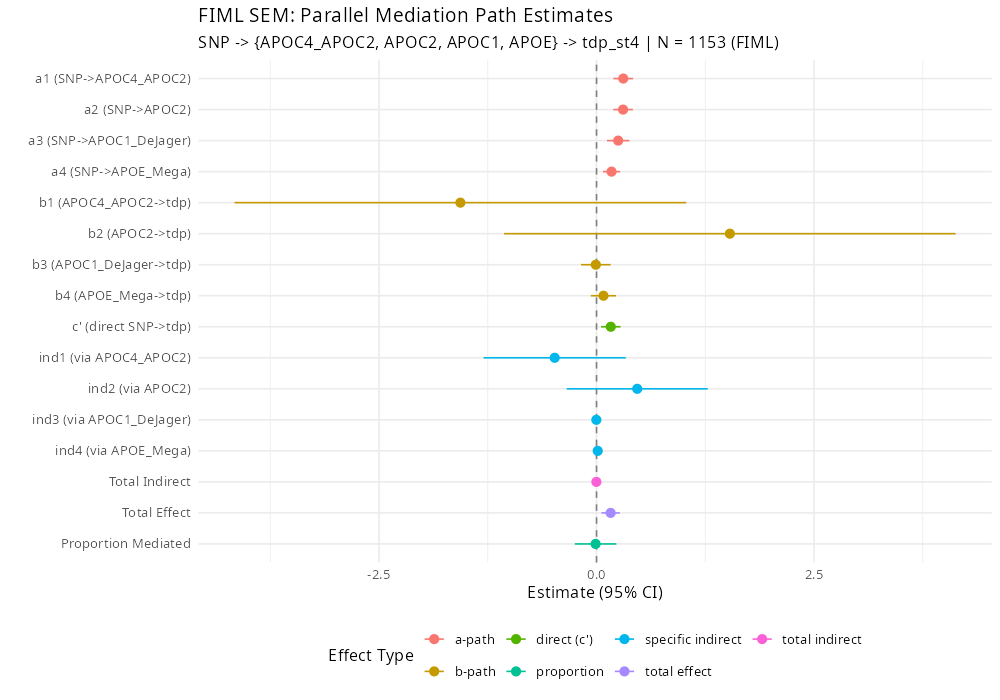

FIML forest plot displayed (files already saved).


In [21]:
# ============================================================
# FIML: Forest plot (from loaded results)
# ============================================================
plot_df <- fiml_res[fiml_res$label %in% key_labels, ]
plot_df$label_f <- factor(plot_df$label, levels=rev(key_labels))
plot_df$display_label <- nice_labels[as.character(plot_df$label)]
plot_df$display_label <- factor(plot_df$display_label, levels=rev(nice_labels[key_labels]))
plot_df$effect_type <- ifelse(grepl("^a", plot_df$label), "a-path",
                       ifelse(grepl("^b", plot_df$label), "b-path",
                       ifelse(plot_df$label == "cp", "direct (c')",
                       ifelse(grepl("^ind[0-9]", plot_df$label), "specific indirect",
                       ifelse(plot_df$label == "total_indirect", "total indirect",
                       ifelse(plot_df$label == "total", "total effect", "proportion"))))))

p_fiml <- ggplot(plot_df, aes(x=est, y=display_label, color=effect_type)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(aes(xmin=ci_lower, xmax=ci_upper), size=0.5) +
  labs(title="FIML SEM: Parallel Mediation Path Estimates",
       subtitle=paste0("SNP -> {APOC4_APOC2, APOC2, APOC1, APOE} -> tdp_st4 | N = ", N_fiml, " (FIML)"),
       x="Estimate (95% CI)", y="", color="Effect Type") +
  theme_minimal(base_size=12) +
  theme(legend.position="bottom")
print(p_fiml)
cat("FIML forest plot displayed (files already saved).\n")


### FIML Interpretation

The FIML results show the path coefficients from the parallel mediation model. Key quantities:
- **a-paths** (a1-a4): Effect of SNP on each mediator (gene expression)
- **b-paths** (b1-b4): Effect of each mediator on tdp_st4 (controlling for SNP and other mediators)
- **c' (direct)**: Direct SNP effect on tdp_st4 (controlling for all mediators)
- **Specific indirect effects** (ind1-ind4): Mediation through each individual pathway
- **Total indirect**: Sum of all specific indirect effects
- **Proportion mediated**: Fraction of total effect operating through the mediators

### Sensitivity Analysis: 3-Mediator Model (Excluding APOC4_APOC2_AC_exp)

The 4-mediator model revealed large but opposing indirect effects through APOC4_APOC2_AC_exp (ind1 = -0.481) and APOC2_AC_exp (ind2 = 0.468), suggesting collinearity-driven suppression. These two mediators measure overlapping gene expression (APOC4-APOC2 fusion transcript vs APOC2 alone).

**Key question:** Does removing APOC4_APOC2_AC_exp allow APOC2_AC_exp to emerge as a significant mediator?

This sensitivity analysis re-fits the parallel mediation model with only 3 mediators:
- APOC2_AC_exp (covariates: msex_u, age_death_u, pmi_u, ROS_study_u)
- APOC1_DeJager_Mic_exp (covariates: msex_u, age_death_u, pmi_u)
- APOE_Mega_Mic_exp (covariates: msex_u, age_death_u, pmi_u)

Data loaded: 1153 rows, 58 columns
N with exposure observed: 1153 

=== Sensitivity Model (3 Mediators, excluding APOC4_APOC2_AC_exp) ===
APOC2_AC_exp ~ a1 * chr19_45001091_C_G + msex_u + age_death_u + pmi_u + ROS_study_u
APOC1_DeJager_Mic_exp ~ a2 * chr19_45001091_C_G + msex_u + age_death_u + pmi_u
APOE_Mega_Mic_exp ~ a3 * chr19_45001091_C_G + msex_u + age_death_u + pmi_u
tdp_st4 ~ b1 * APOC2_AC_exp + b2 * APOC1_DeJager_Mic_exp + b3 * APOE_Mega_Mic_exp + cp * chr19_45001091_C_G + educ + apoe4_dose + apoe2_dose + msex_u + age_death_u
ind1 := a1 * b1
ind2 := a2 * b2
ind3 := a3 * b3
total_indirect := ind1 + ind2 + ind3
total := cp + total_indirect
prop_med := total_indirect / total
diff_1_2 := ind1 - ind2
diff_1_3 := ind1 - ind3
diff_2_3 := ind2 - ind3
APOC2_AC_exp ~~ APOC1_DeJager_Mic_exp
APOC2_AC_exp ~~ APOE_Mega_Mic_exp
APOC1_DeJager_Mic_exp ~~ APOE_Mega_Mic_exp 

FIML converged. N = 1153 

=== Sensitivity Analysis Results (3 mediators, no APOC4_APOC2_AC_exp) ===
            label    

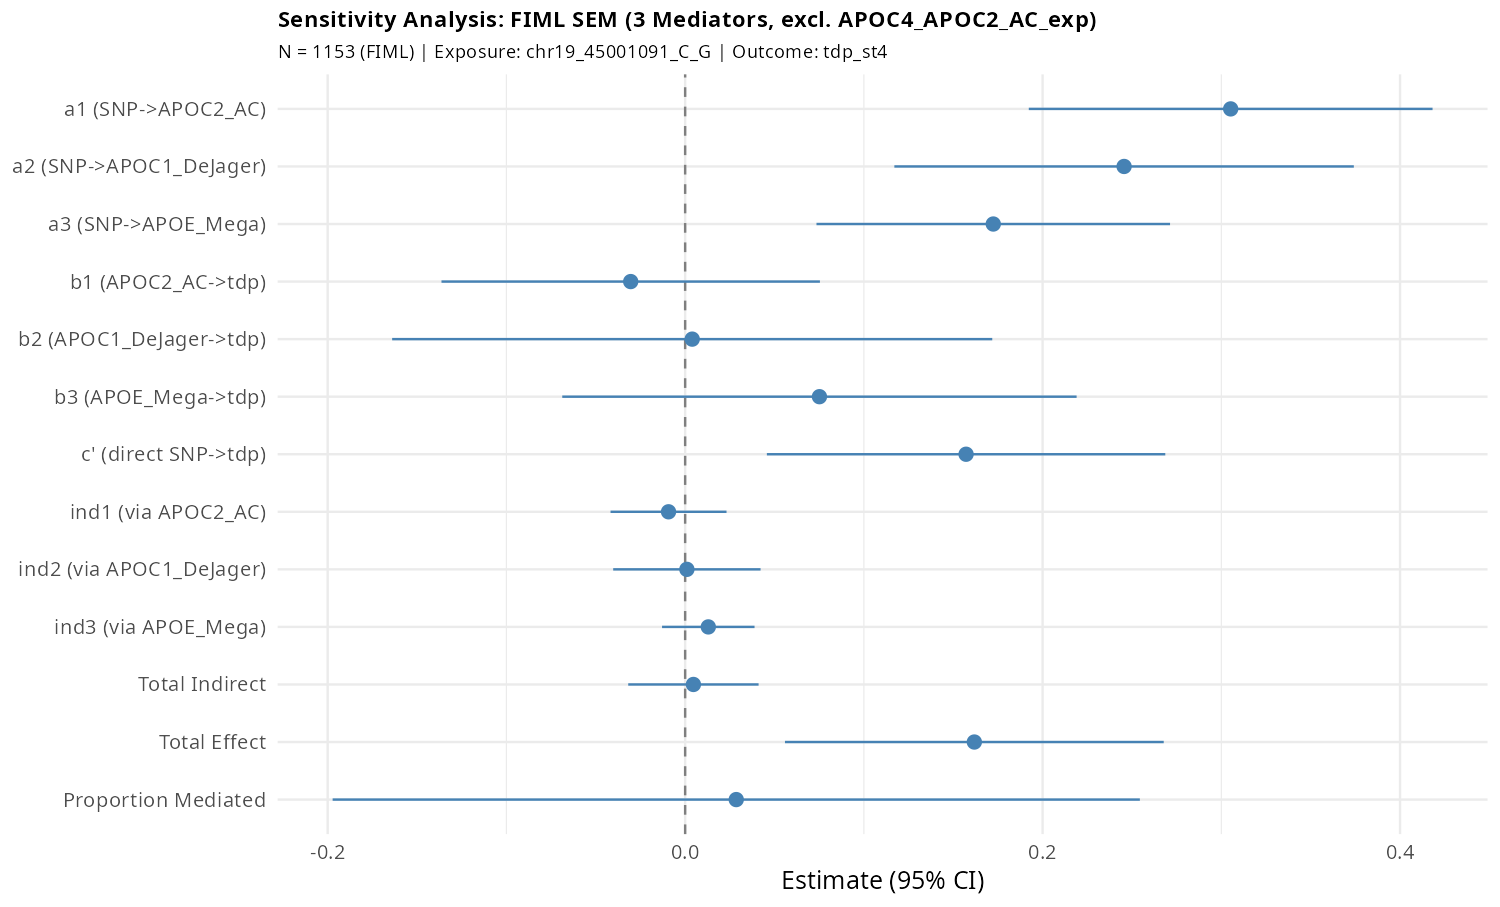

In [99]:
# ============================================================
# SENSITIVITY ANALYSIS: Parallel Mediation WITHOUT APOC4_APOC2_AC_exp
# ============================================================

sens_dir <- file.path(RESULT_DIR, "main_SEM_FIML", "sensitivity_analysis")
dir.create(sens_dir, showWarnings=FALSE, recursive=TRUE)

# 3-mediator setup
sens_med_cols <- c("APOC2_AC_exp", "APOC1_DeJager_Mic_exp", "APOE_Mega_Mic_exp")
sens_n_med <- length(sens_med_cols)

sens_med_covs <- list(
  APOC2_AC_exp           = c("msex_u", "age_death_u", "pmi_u", "ROS_study_u"),
  APOC1_DeJager_Mic_exp  = c("msex_u", "age_death_u", "pmi_u"),
  APOE_Mega_Mic_exp      = c("msex_u", "age_death_u", "pmi_u")
)

# Build model
sens_med_eqs <- c()
for (i in seq_len(sens_n_med)) {
  cov_str <- paste(sens_med_covs[[sens_med_cols[i]]], collapse=" + ")
  eq <- paste0(sens_med_cols[i], " ~ a", i, " * ", exposure, " + ", cov_str)
  sens_med_eqs <- c(sens_med_eqs, eq)
}

sens_med_terms <- paste0("b", seq_len(sens_n_med), " * ", sens_med_cols, collapse=" + ")
sens_y_eq <- paste0(outcome, " ~ ", sens_med_terms, " + cp * ", exposure, " + ", paste(out_covs, collapse=" + "))

sens_ind_defs <- paste0("ind", seq_len(sens_n_med), " := a", seq_len(sens_n_med), " * b", seq_len(sens_n_med))
sens_total_ind <- paste0("total_indirect := ", paste0("ind", seq_len(sens_n_med), collapse=" + "))
sens_total_def <- "total := cp + total_indirect"
sens_prop_def <- "prop_med := total_indirect / total"

sens_contrasts <- c()
for (i in 1:(sens_n_med-1)) {
  for (j in (i+1):sens_n_med) {
    sens_contrasts <- c(sens_contrasts, paste0("diff_", i, "_", j, " := ind", i, " - ind", j))
  }
}

sens_cov_terms <- c()
for (i in 1:(sens_n_med-1)) {
  for (j in (i+1):sens_n_med) {
    sens_cov_terms <- c(sens_cov_terms, paste0(sens_med_cols[i], " ~~ ", sens_med_cols[j]))
  }
}

sens_model_str <- paste(c(sens_med_eqs, sens_y_eq, sens_ind_defs, sens_total_ind,
                          sens_total_def, sens_prop_def, sens_contrasts, sens_cov_terms),
                        collapse="\n")

cat("=== Sensitivity Model (3 Mediators, excluding APOC4_APOC2_AC_exp) ===\n")
cat(sens_model_str, "\n\n")

# Fit FIML
sens_fit <- tryCatch(
  sem(sens_model_str, data=dat, missing="fiml", fixed.x=FALSE, estimator="ML"),
  error = function(e) { cat("SEM ERROR:", e$message, "\n"); NULL }
)

if (!is.null(sens_fit) && lavInspect(sens_fit, "converged")) {
  N_sens <- lavInspect(sens_fit, "nobs")
  cat("FIML converged. N =", N_sens, "\n\n")
  
  pe_sens <- parameterEstimates(sens_fit, ci=TRUE)
  
  sens_key_labels <- c(paste0("a", 1:sens_n_med), paste0("b", 1:sens_n_med), "cp",
                       paste0("ind", 1:sens_n_med), "total_indirect", "total", "prop_med")
  
  sens_nice_labels <- c(
    a1="a1 (SNP->APOC2_AC)", a2="a2 (SNP->APOC1_DeJager)", a3="a3 (SNP->APOE_Mega)",
    b1="b1 (APOC2_AC->tdp)", b2="b2 (APOC1_DeJager->tdp)", b3="b3 (APOE_Mega->tdp)",
    cp="c' (direct SNP->tdp)",
    ind1="ind1 (via APOC2_AC)", ind2="ind2 (via APOC1_DeJager)", ind3="ind3 (via APOE_Mega)",
    total_indirect="Total Indirect", total="Total Effect", prop_med="Proportion Mediated"
  )
  
  sens_results <- list()
  for (lab in sens_key_labels) {
    row <- pe_sens[pe_sens$label == lab, ]
    if (nrow(row) == 1) {
      sens_results[[lab]] <- data.frame(
        exposure=exposure, direction="D1", label=lab,
        nice_label=sens_nice_labels[lab],
        est=row$est, se=row$se, ci_lower=row$ci.lower, ci_upper=row$ci.upper,
        pvalue=row$pvalue, N=N_sens, method="FIML_sensitivity_3med",
        stringsAsFactors=FALSE
      )
    }
  }
  sens_df <- do.call(rbind, sens_results)
  rownames(sens_df) <- NULL
  
  cat("=== Sensitivity Analysis Results ===\n")
  print(sens_df[, c("label", "nice_label", "est", "se", "ci_lower", "ci_upper", "pvalue", "N")], digits=4)
  
  # Save CSV
  write.csv(sens_df, file.path(sens_dir, "fiml_sensitivity_3med.csv"), row.names=FALSE)
  cat("\nCSV saved:", file.path(sens_dir, "fiml_sensitivity_3med.csv"), "\n")
  
  # Comparison with 4-mediator model
  orig_path <- file.path(dir_fiml, "fiml_all_paths.csv")
  if (file.exists(orig_path)) {
    orig <- read.csv(orig_path, stringsAsFactors=FALSE)
    compare_df <- data.frame(
      Effect = c("b-path (APOC2_AC->tdp)", "Indirect (via APOC2_AC)",
                 "Total Indirect", "Direct (c')", "Total Effect"),
      `4med_est` = c(orig$est[orig$label=="b2"], orig$est[orig$label=="ind2"],
                     orig$est[orig$label=="total_indirect"], orig$est[orig$label=="cp"],
                     orig$est[orig$label=="total"]),
      `4med_p` = c(orig$pvalue[orig$label=="b2"], orig$pvalue[orig$label=="ind2"],
                   orig$pvalue[orig$label=="total_indirect"], orig$pvalue[orig$label=="cp"],
                   orig$pvalue[orig$label=="total"]),
      `3med_est` = c(sens_df$est[sens_df$label=="b1"], sens_df$est[sens_df$label=="ind1"],
                     sens_df$est[sens_df$label=="total_indirect"], sens_df$est[sens_df$label=="cp"],
                     sens_df$est[sens_df$label=="total"]),
      `3med_p` = c(sens_df$pvalue[sens_df$label=="b1"], sens_df$pvalue[sens_df$label=="ind1"],
                   sens_df$pvalue[sens_df$label=="total_indirect"], sens_df$pvalue[sens_df$label=="cp"],
                   sens_df$pvalue[sens_df$label=="total"]),
      stringsAsFactors=FALSE, check.names=FALSE
    )
    cat("\n=== Comparison: 4-Mediator vs 3-Mediator Model ===\n")
    print(compare_df, digits=4)
    write.csv(compare_df, file.path(sens_dir, "comparison_4med_vs_3med.csv"), row.names=FALSE)
  }
  
  # Forest plot
  plot_df <- sens_df[sens_df$label %in% sens_key_labels, ]
  plot_df$nice_label <- factor(plot_df$nice_label, levels=rev(sens_nice_labels[sens_key_labels]))
  
  p_sens <- ggplot(plot_df, aes(x=est, y=nice_label, xmin=ci_lower, xmax=ci_upper)) +
    geom_vline(xintercept=0, linetype="dashed", color="grey50") +
    geom_pointrange(color="steelblue", size=0.5) +
    labs(
      title="Sensitivity Analysis: FIML SEM (3 Mediators, excl. APOC4_APOC2_AC_exp)",
      subtitle=paste0("N = ", N_sens, " (FIML) | Exposure: ", exposure, " | Outcome: ", outcome),
      x="Estimate (95% CI)", y=NULL
    ) +
    theme_minimal(base_size=12) +
    theme(plot.title=element_text(size=11, face="bold"), plot.subtitle=element_text(size=9))
  
  plot_h <- max(5, nrow(plot_df) * 0.35 + 1.5)
  ggsave(file.path(sens_dir, "fiml_sensitivity_3med_forest.png"), p_sens,
         width=10, height=plot_h, dpi=150, limitsize=FALSE)
  ggsave(file.path(sens_dir, "fiml_sensitivity_3med_forest.pdf"), p_sens,
         width=10, height=plot_h, limitsize=FALSE)
  print(p_sens)
  cat("\nForest plots saved.\n")
  
  # Key finding
  ind1_p <- sens_df$pvalue[sens_df$label == "ind1"]
  ind1_est <- sens_df$est[sens_df$label == "ind1"]
  b1_p <- sens_df$pvalue[sens_df$label == "b1"]
  b1_est <- sens_df$est[sens_df$label == "b1"]
  ti_p <- sens_df$pvalue[sens_df$label == "total_indirect"]
  ti_est <- sens_df$est[sens_df$label == "total_indirect"]
  
  cat("\n=== KEY FINDING ===\n")
  cat(sprintf("APOC2_AC_exp b-path:   est=%.4f, p=%.4f (%s)\n", b1_est, b1_p,
              ifelse(b1_p < 0.05, "SIGNIFICANT", "not significant")))
  cat(sprintf("APOC2_AC_exp indirect: est=%.4f, p=%.4f (%s)\n", ind1_est, ind1_p,
              ifelse(ind1_p < 0.05, "SIGNIFICANT", "not significant")))
  cat(sprintf("Total indirect:        est=%.4f, p=%.4f (%s)\n", ti_est, ti_p,
              ifelse(ti_p < 0.05, "SIGNIFICANT", "not significant")))
  
  if (ind1_p >= 0.05) {
    cat("\nConclusion: Removing APOC4_APOC2_AC_exp does NOT make APOC2_AC_exp significant.\n")
    cat("The suppression effect was artifactual collinearity, not masking a real mediation signal.\n")
  } else {
    cat("\nConclusion: Removing APOC4_APOC2_AC_exp DOES make APOC2_AC_exp significant!\n")
    cat("The suppression effect was masking a genuine mediation pathway through APOC2_AC_exp.\n")
  }
} else {
  cat("ERROR: Sensitivity FIML did not converge.\n")
}

---
## Method 2: Bootstrap (FIML Inside Each Replicate)

Non-parametric bootstrap with FIML SEM inside each replicate. This provides percentile confidence intervals that do not assume normality of the indirect effect distribution. 1000 resamples of the full dataset.

In [22]:
# ============================================================
# BOOTSTRAP: Load previously computed results
# ============================================================
cat("Loading Bootstrap results from CSV (already computed)...\n")

boot_summary <- read.csv(file.path(dir_boot, "bootstrap_results.csv"), stringsAsFactors=FALSE)
n_converged <- boot_summary$n_converged[1]
B <- 1000  # original number of replicates

cat("=== Bootstrap Results (loaded) ===\n")
print(boot_summary[boot_summary$label %in% key_labels, c("label", "est", "se", "ci_lower", "ci_upper", "pvalue")])
cat(sprintf("\nBootstrap: %d/%d converged\n", n_converged, B))


Loading Bootstrap results from CSV (already computed)...
=== Bootstrap Results (loaded) ===
            label          est         se    ci_lower   ci_upper pvalue
1              a1  0.309801518 0.05697373  0.19958362 0.42008011  0.000
2              a2  0.307610239 0.05727292  0.19686237 0.41759542  0.000
3              a3  0.249416015 0.06522680  0.12844105 0.38332076  0.000
4              a4  0.174839894 0.04916388  0.08016570 0.26691441  0.000
5              b1 -1.563669048 1.35058642 -4.17932564 1.05352036  0.244
6              b2  1.530685288 1.34932553 -1.10542100 4.14489659  0.260
7              b3 -0.010305205 0.09089422 -0.18525135 0.17405443  0.890
8              b4  0.081997760 0.07674822 -0.06890696 0.22841881  0.280
9              cp  0.163636786 0.05880451  0.05657163 0.28336728  0.002
10           ind1 -0.483344705 0.44065229 -1.40619721 0.33166531  0.244
11           ind2  0.469770712 0.43711513 -0.32477765 1.38819774  0.260
12           ind3 -0.003027796 0.02364969 -0

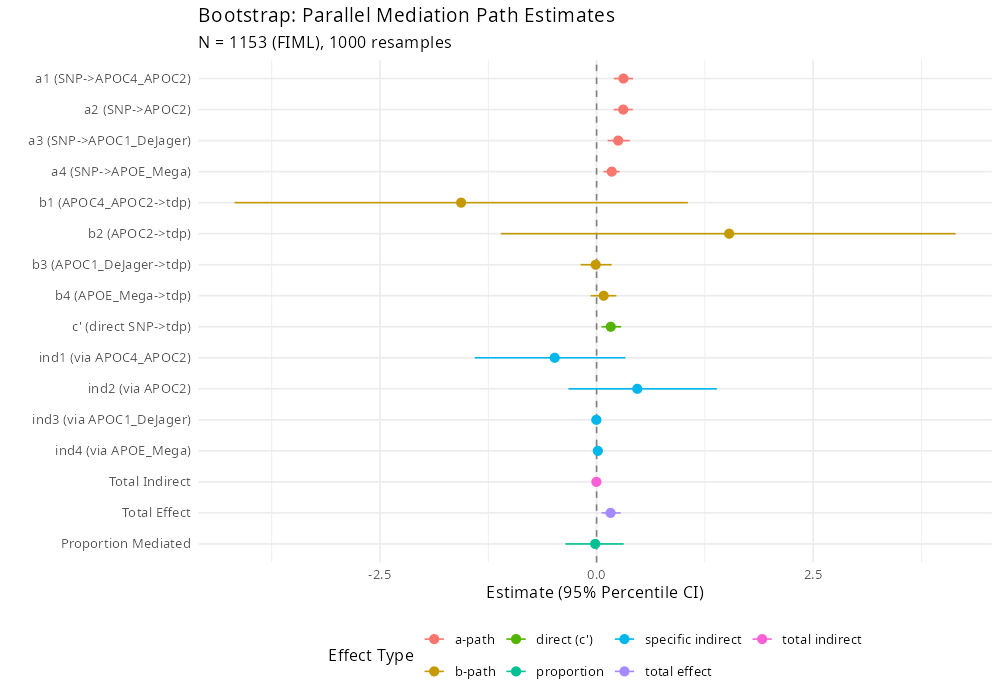

Bootstrap forest plot displayed (files already saved).


In [23]:
# ============================================================
# BOOTSTRAP: Forest plot (from loaded results)
# ============================================================
boot_plot <- boot_summary[boot_summary$label %in% key_labels, ]
boot_plot$display_label <- nice_labels[boot_plot$label]
boot_plot$display_label <- factor(boot_plot$display_label, levels=rev(nice_labels[key_labels]))
boot_plot$effect_type <- ifelse(grepl("^a", boot_plot$label), "a-path",
                         ifelse(grepl("^b", boot_plot$label), "b-path",
                         ifelse(boot_plot$label == "cp", "direct (c')",
                         ifelse(grepl("^ind[0-9]", boot_plot$label), "specific indirect",
                         ifelse(boot_plot$label == "total_indirect", "total indirect",
                         ifelse(boot_plot$label == "total", "total effect", "proportion"))))))

p_boot_forest <- ggplot(boot_plot, aes(x=est, y=display_label, color=effect_type)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(aes(xmin=ci_lower, xmax=ci_upper), size=0.5) +
  labs(title="Bootstrap: Parallel Mediation Path Estimates",
       subtitle=paste0("N = ", N_total, " (FIML), ", n_converged, " resamples"),
       x="Estimate (95% Percentile CI)", y="", color="Effect Type") +
  theme_minimal(base_size=12) +
  theme(legend.position="bottom")
print(p_boot_forest)
cat("Bootstrap forest plot displayed (files already saved).\n")


### Bootstrap Interpretation

The bootstrap results provide non-parametric percentile confidence intervals. The key comparison with FIML:
- If bootstrap CIs are similar to FIML CIs, the normality assumption for the indirect effect is reasonable
- If bootstrap CIs are wider or shifted, the indirect effect distribution may be skewed
- The convergence rate indicates model stability across resampled datasets

---
## Method 3: MNAR Sensitivity Analysis

Assesses robustness of mediation results to departures from the Missing At Random (MAR) assumption. For each point on a 2D grid (delta_mediators x delta_outcome), missing values are imputed at `mean + delta * SD`, then the model is re-fit with ML. The tipping point is the minimum delta distance where the indirect effect becomes non-significant.

In [24]:
# ============================================================
# MNAR SENSITIVITY: Load previously computed results
# ============================================================
cat("Loading MNAR results from CSV (already computed)...\n")

mnar_grid <- read.csv(file.path(dir_mnar, "mnar_grid_results.csv"), stringsAsFactors=FALSE)
tip_df <- read.csv(file.path(dir_mnar, "mnar_tipping_summary.csv"), stringsAsFactors=FALSE)
tip_dist <- tip_df$tipping_dist_SD[1]

cat(sprintf("MNAR grid: %d points\n", nrow(mnar_grid)))
cat(sprintf("Tipping point distance: %.2f SD\n", tip_dist))
cat(sprintf("Origin estimate: %.5f, p = %.4f\n", tip_df$origin_est[1], tip_df$origin_p[1]))


Loading MNAR results from CSV (already computed)...
MNAR grid: 225 points
Tipping point distance: 1.55 SD
Origin estimate: 0.00030, p = 0.9749


In [25]:
# ============================================================
# MNAR: Display contour plots (already saved)
# ============================================================
cat("MNAR contour plots and 1D slices already saved to disk.\n")
cat("Files:\n")
cat("  mnar_contour_indirect_chr19_45001091_C_G.png\n")
cat("  mnar_contour_pvalue_chr19_45001091_C_G.png\n")
cat("  mnar_1d_slices_chr19_45001091_C_G.png\n")


MNAR contour plots and 1D slices already saved to disk.
Files:
  mnar_contour_indirect_chr19_45001091_C_G.png
  mnar_contour_pvalue_chr19_45001091_C_G.png
  mnar_1d_slices_chr19_45001091_C_G.png


### MNAR Interpretation

The MNAR sensitivity analysis examines how robust the mediation result is to departures from the Missing At Random assumption. The tipping point distance (in SD units) tells us how far the missing data mechanism would need to deviate from MAR before the indirect effect becomes non-significant. A tipping point > 1.0 SD is generally considered robust; < 0.5 SD is fragile.

---
## Method 4: Bayesian SEM (blavaan / Stan)

Bayesian estimation via Stan provides posterior distributions for all parameters, enabling direct probability statements (e.g., P(indirect > 0)). Missing data is handled via Stan's data augmentation. Using 4 chains with 1000 burnin + 2000 sampling iterations each.

In [5]:
# ============================================================
# BAYESIAN SEM: Fit model (blavaan)
# ============================================================
cat("Fitting Bayesian SEM via blavaan/Stan...\n")
cat("This may take 30-60 minutes for a parallel mediation model with 4 mediators.\n")
cat("Start time:", format(Sys.time()), "\n\n")

fit_bayes <- tryCatch(
  bsem(model_str, data=dat, fixed.x=FALSE, target="stan",
       n.chains=4, burnin=1000, sample=2000, seed=42),
  error = function(e) {
    cat("blavaan error (4 chains):", e$message, "\n")
    cat("Retrying with 2 chains and more iterations...\n")
    tryCatch(
      bsem(model_str, data=dat, fixed.x=FALSE, target="stan",
           n.chains=2, burnin=1500, sample=3000, seed=42),
      error = function(e2) {
        cat("blavaan retry error:", e2$message, "\n")
        NULL
      }
    )
  }
)

if (!is.null(fit_bayes)) {
  cat("Bayesian SEM fit complete at:", format(Sys.time()), "\n")
} else {
  cat("WARNING: Bayesian SEM failed completely.\n")
}


Fitting Bayesian SEM via blavaan/Stan...


This may take 30-60 minutes for a parallel mediation model with 4 mediators.


Start time: 2026-04-01 00:33:46 




SAMPLING FOR MODEL 'stanmarg' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.006033 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 60.33 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 3000 [  0%]  (Warmup)
Chain 1: Iteration:  300 / 3000 [ 10%]  (Warmup)
Chain 1: Iteration:  600 / 3000 [ 20%]  (Warmup)
Chain 1: Iteration:  900 / 3000 [ 30%]  (Warmup)
Chain 1: Iteration: 1001 / 3000 [ 33%]  (Sampling)
Chain 1: Iteration: 1300 / 3000 [ 43%]  (Sampling)
Chain 1: Iteration: 1600 / 3000 [ 53%]  (Sampling)
Chain 1: Iteration: 1900 / 3000 [ 63%]  (Sampling)
Chain 1: Iteration: 2200 / 3000 [ 73%]  (Sampling)
Chain 1: Iteration: 2500 / 3000 [ 83%]  (Sampling)
Chain 1: Iteration: 2800 / 3000 [ 93%]  (Sampling)
Chain 1: Iteration: 3000 / 3000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 1919.15 seconds (Warm-up)
Chain 1:                4454.56 seconds (Sampling)
Chain 1:            

Warning message:
“There were 8000 transitions after warmup that exceeded the maximum treedepth. Increase max_treedepth above 10. See
https://mc-stan.org/misc/warnings.html#maximum-treedepth-exceeded”


...

Warning message:
“Bulk Effective Samples Size (ESS) is too low, indicating posterior means and medians may be unreliable.
Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#bulk-ess”


Warning message:
“Tail Effective Samples Size (ESS) is too low, indicating posterior variances and tail quantiles may be unreliable.
Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#tail-ess”


Computing post-estimation metrics (including lvs if requested)...


Warning message:
“lavaan->lav_model_vcov_se():  
   The following boostrapped defined parameters have a high (>5) ratio of 
   standard deviation to median absolute deviation: prop_med. P-values and 
   confidence intervals may not match.”


Bayesian SEM fit complete at: 2026-04-01 07:41:21 


In [6]:
# ============================================================
# BAYESIAN: Robust parameter extraction
# ============================================================
if (!is.null(fit_bayes)) {
  
  # Step 1: Get parTable and posterior draws
  pt <- parTable(fit_bayes)
  cat("=== parTable: labeled rows ===\n")
  labeled_rows <- pt[pt$label != "", ]
  print(labeled_rows[, c("id", "lhs", "op", "rhs", "label", "est", "se")])
  
  # Step 2: Get posterior draws
  draws <- tryCatch({
    d <- blavInspect(fit_bayes, "mcmc")
    if (is.list(d)) do.call(rbind, d) else as.matrix(d)
  }, error = function(e) {
    cat("Note: blavInspect('mcmc') failed, trying 'draws'...\n")
    tryCatch({
      d <- blavInspect(fit_bayes, "draws")
      if (is.list(d)) do.call(rbind, d) else as.matrix(d)
    }, error = function(e2) {
      cat("Note: blavInspect('draws') also failed.\n")
      NULL
    })
  })
  
  if (!is.null(draws)) {
    cat("\nPosterior draw matrix:", nrow(draws), "draws x", ncol(draws), "columns\n")
    cat("Column names:\n")
    print(colnames(draws))
  }
  
  # Step 3: Map regression labels (a1, a2, ..., b1, ..., cp) to draw columns
  # blavaan uses internal Stan parameter names like "bet_sign[k]" in draws
  # We need to match parTable rows to draw columns
  
  # Get pxnames: maps parTable free parameters to Stan variable names
  pxnames <- tryCatch(blavInspect(fit_bayes, "pxnames"), error = function(e) NULL)
  if (!is.null(pxnames)) {
    cat("\npxnames (parTable row -> Stan name mapping):\n")
    print(pxnames)
  }
  
  # Build label -> draw column mapping for regression params only (~ and ~~)
  reg_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp")
  label_to_drawcol <- list()
  
  draw_cols <- if (!is.null(draws)) colnames(draws) else character(0)
  
  for (lab in reg_labels) {
    # Method 1: label directly matches a draw column
    if (lab %in% draw_cols) {
      label_to_drawcol[[lab]] <- lab
      next
    }
    
    # Method 2: use pxnames to map parTable row -> Stan name
    if (!is.null(pxnames)) {
      pt_rows_with_lab <- which(pt$label == lab & pt$op %in% c("~", "~~"))
      for (row_idx in pt_rows_with_lab) {
        if (row_idx <= length(pxnames)) {
          px <- pxnames[row_idx]
          if (!is.na(px) && px %in% draw_cols) {
            label_to_drawcol[[lab]] <- px
            break
          }
        }
      }
    }
    
    # Method 3: try parameterEstimates (may work for some blavaan versions)
    if (!(lab %in% names(label_to_drawcol))) {
      # Try matching by lhs/op/rhs
      pt_match <- pt[pt$label == lab & pt$op == "~", ]
      if (nrow(pt_match) > 0) {
        # Search draw columns for patterns matching this parameter
        # blavaan often uses "bet_sign[N]" where N is the free param index
        free_idx <- pt_match$free[1]
        if (!is.na(free_idx) && free_idx > 0) {
          candidate <- paste0("bet_sign[", free_idx, "]")
          if (candidate %in% draw_cols) {
            label_to_drawcol[[lab]] <- candidate
          }
        }
      }
    }
  }
  
  cat("\n=== Label -> Draw Column Mapping (regression params) ===\n")
  for (nm in names(label_to_drawcol)) {
    cat(sprintf("  %s -> %s\n", nm, label_to_drawcol[[nm]]))
  }
  unmapped <- setdiff(reg_labels, names(label_to_drawcol))
  if (length(unmapped) > 0) {
    cat("  UNMAPPED:", paste(unmapped, collapse=", "), "\n")
  }
  
  # Step 4: Extract posterior draws for regression params and compute defined params
  post_draws_list <- list()
  
  # Get regression param draws
  for (lab in reg_labels) {
    if (lab %in% names(label_to_drawcol)) {
      dcol <- label_to_drawcol[[lab]]
      post_draws_list[[lab]] <- draws[, dcol]
    }
  }
  
  # Compute defined params from component draws
  # ind_i = a_i * b_i
  for (i in 1:n_med) {
    a_lab <- paste0("a", i)
    b_lab <- paste0("b", i)
    if (a_lab %in% names(post_draws_list) && b_lab %in% names(post_draws_list)) {
      post_draws_list[[paste0("ind", i)]] <- post_draws_list[[a_lab]] * post_draws_list[[b_lab]]
    }
  }
  
  # total_indirect = sum of all ind_i
  ind_labs <- paste0("ind", 1:n_med)
  avail_ind <- intersect(ind_labs, names(post_draws_list))
  if (length(avail_ind) == n_med) {
    total_ind_draws <- Reduce("+", post_draws_list[avail_ind])
    post_draws_list[["total_indirect"]] <- total_ind_draws
  }
  
  # total = cp + total_indirect
  if ("cp" %in% names(post_draws_list) && "total_indirect" %in% names(post_draws_list)) {
    post_draws_list[["total"]] <- post_draws_list[["cp"]] + post_draws_list[["total_indirect"]]
  }
  
  # prop_med = total_indirect / total
  if ("total_indirect" %in% names(post_draws_list) && "total" %in% names(post_draws_list)) {
    total_d <- post_draws_list[["total"]]
    # Avoid division by zero: use NA where total is very close to 0
    prop_d <- ifelse(abs(total_d) > 1e-10, post_draws_list[["total_indirect"]] / total_d, NA)
    post_draws_list[["prop_med"]] <- prop_d
  }
  
  # Pairwise contrasts
  for (i in 1:(n_med-1)) {
    for (j in (i+1):n_med) {
      ind_i <- paste0("ind", i)
      ind_j <- paste0("ind", j)
      diff_lab <- paste0("diff_", i, "_", j)
      if (ind_i %in% names(post_draws_list) && ind_j %in% names(post_draws_list)) {
        post_draws_list[[diff_lab]] <- post_draws_list[[ind_i]] - post_draws_list[[ind_j]]
      }
    }
  }
  
  cat("\n=== Available posterior draws ===\n")
  cat("Parameters:", paste(names(post_draws_list), collapse=", "), "\n")
  cat("N draws per parameter:", if (length(post_draws_list) > 0) length(post_draws_list[[1]]) else 0, "\n")
  
  # Step 5: Build results data.frame
  bayes_rows <- list()
  
  all_labels <- c(key_labels, 
                  paste0("diff_", apply(combn(1:n_med, 2), 2, paste, collapse="_")))
  
  for (lab in all_labels) {
    if (lab %in% names(post_draws_list)) {
      pd <- post_draws_list[[lab]]
      pd_clean <- pd[!is.na(pd)]
      if (length(pd_clean) > 0) {
        bayes_rows[[length(bayes_rows) + 1]] <- data.frame(
          exposure = exposure,
          direction = "D1",
          label = lab,
          est = mean(pd_clean),
          se = sd(pd_clean),
          ci_lower = as.numeric(quantile(pd_clean, 0.025)),
          ci_upper = as.numeric(quantile(pd_clean, 0.975)),
          pp_direction = mean(pd_clean > 0),
          N = N_total,
          method = "Bayesian",
          stringsAsFactors = FALSE
        )
      }
    } else {
      # Fall back to parTable estimates if draws unavailable
      pt_row <- pt[pt$label == lab, ]
      if (nrow(pt_row) > 0) {
        est_val <- pt_row$est[1]
        se_val <- pt_row$se[1]
        bayes_rows[[length(bayes_rows) + 1]] <- data.frame(
          exposure = exposure,
          direction = "D1",
          label = lab,
          est = est_val,
          se = se_val,
          ci_lower = est_val - 1.96 * se_val,
          ci_upper = est_val + 1.96 * se_val,
          pp_direction = NA,
          N = N_total,
          method = "Bayesian",
          stringsAsFactors = FALSE
        )
      }
    }
  }
  
  if (length(bayes_rows) > 0) {
    bayes_results <- do.call(rbind, bayes_rows)
    write.csv(bayes_results, file.path(dir_bayes, "bayesian_results.csv"), row.names=FALSE)
    cat("\n=== Bayesian Results ===\n")
    print(bayes_results[, c("label", "est", "se", "ci_lower", "ci_upper", "pp_direction")])
  } else {
    cat("WARNING: No Bayesian results could be extracted.\n")
    bayes_results <- NULL
  }
} else {
  bayes_results <- NULL
  cat("Bayesian SEM was not fitted successfully.\n")
}


=== parTable: labeled rows ===
     id                   lhs op                   rhs          label    est
1     1    APOC4_APOC2_AC_exp  ~    chr19_45001091_C_G             a1  0.308
6     6          APOC2_AC_exp  ~    chr19_45001091_C_G             a2  0.306
11   11 APOC1_DeJager_Mic_exp  ~    chr19_45001091_C_G             a3  0.251
15   15     APOE_Mega_Mic_exp  ~    chr19_45001091_C_G             a4  0.176
19   19               tdp_st4  ~    APOC4_APOC2_AC_exp             b1 -1.642
20   20               tdp_st4  ~          APOC2_AC_exp             b2  1.613
21   21               tdp_st4  ~ APOC1_DeJager_Mic_exp             b3 -0.013
22   22               tdp_st4  ~     APOE_Mega_Mic_exp             b4  0.083
23   23               tdp_st4  ~    chr19_45001091_C_G             cp  0.164
89   89                  ind1 :=                 a1*b1           ind1 -0.507
90   90                  ind2 :=                 a2*b2           ind2  0.494
91   91                  ind3 :=             

Saved Bayesian posterior density plots.


Saved trace plot.


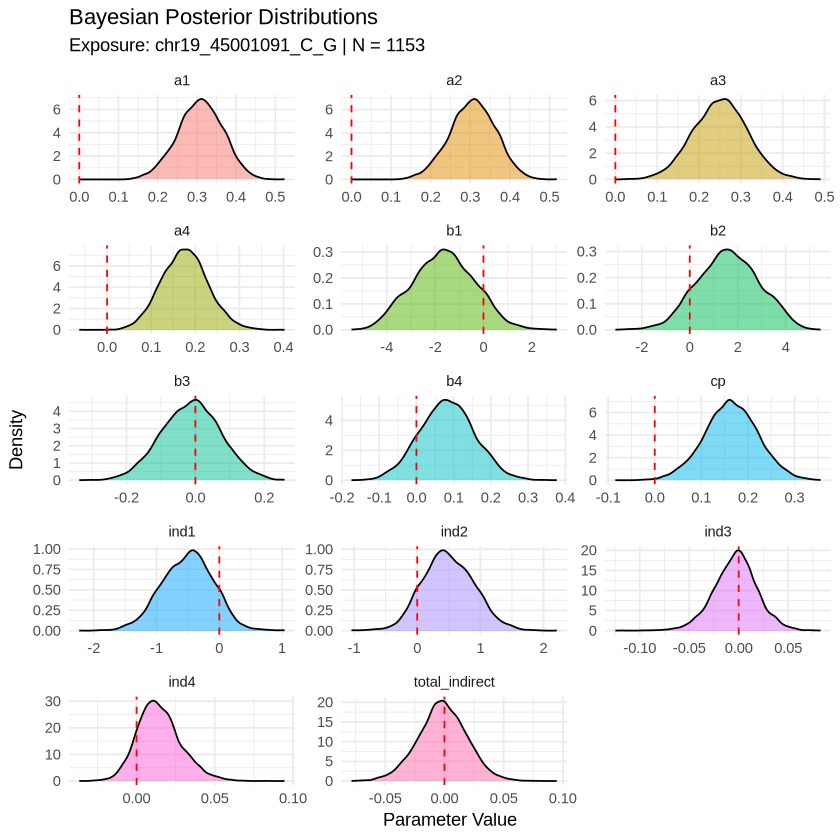

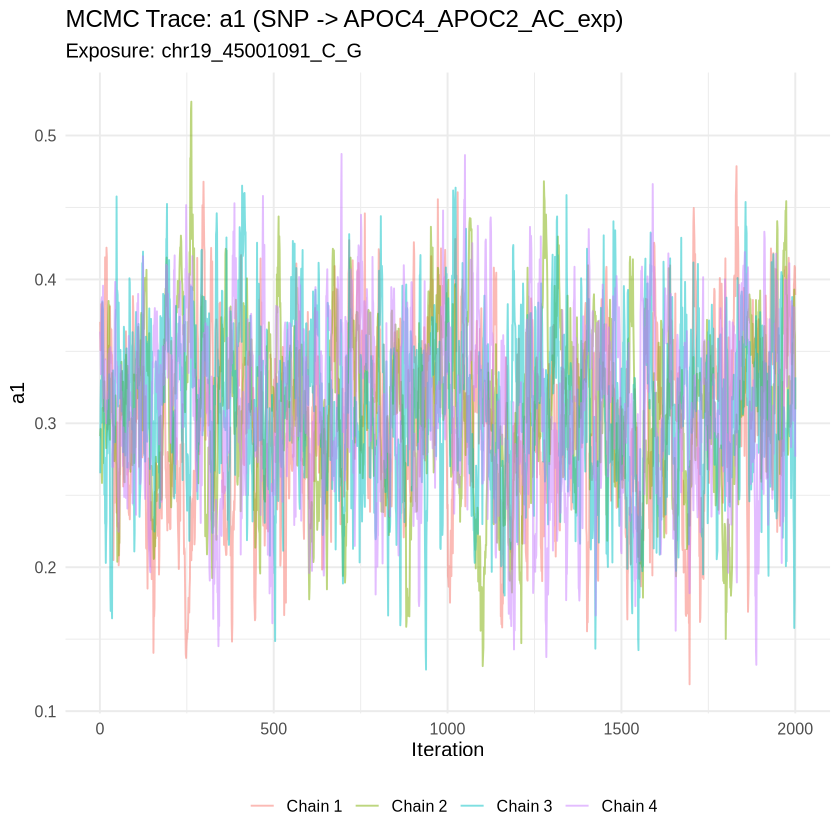

Saved Bayesian forest plot.


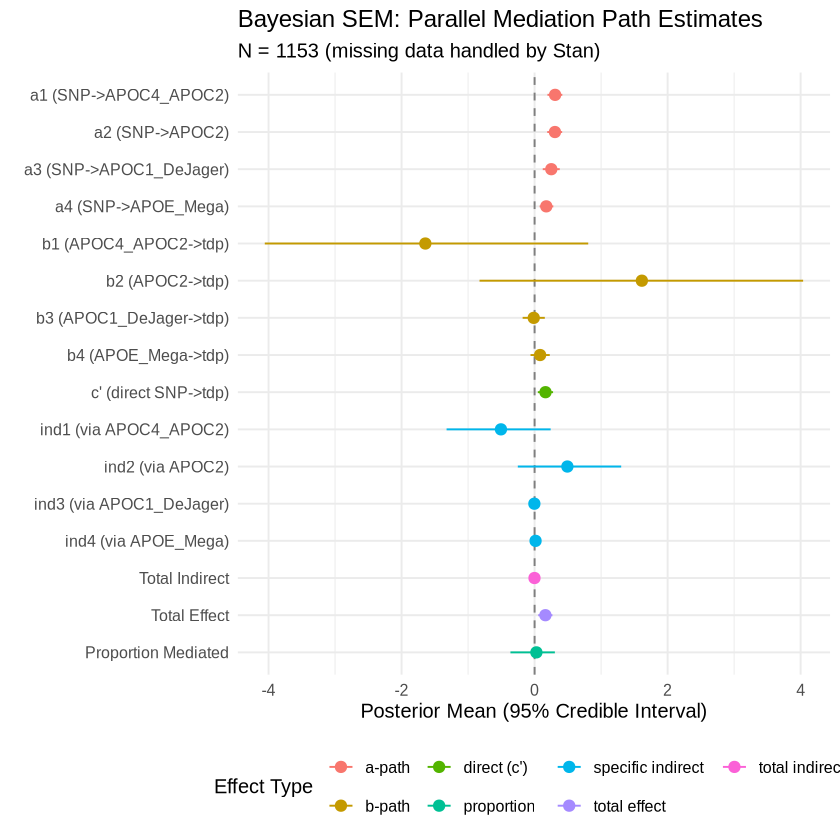

In [7]:
# ============================================================
# BAYESIAN: Posterior density plots, trace plot, forest plot
# ============================================================
if (!is.null(fit_bayes) && exists("bayes_results") && !is.null(bayes_results) && nrow(bayes_results) > 0) {
  
  # --- Posterior density plots ---
  density_params <- intersect(names(post_draws_list),
                              c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                                paste0("ind", 1:n_med), "total_indirect"))
  
  if (length(density_params) > 0) {
    dens_list <- list()
    for (lab in density_params) {
      pd <- post_draws_list[[lab]]
      pd_clean <- pd[!is.na(pd)]
      if (length(pd_clean) > 10) {
        dens_list[[lab]] <- data.frame(value=pd_clean, parameter=lab, stringsAsFactors=FALSE)
      }
    }
    
    if (length(dens_list) > 0) {
      dens_data <- do.call(rbind, dens_list)
      
      p_dens <- ggplot(dens_data, aes(x=value, fill=parameter)) +
        geom_density(alpha=0.5) +
        geom_vline(xintercept=0, linetype="dashed", color="red") +
        facet_wrap(~parameter, scales="free", ncol=3) +
        labs(title="Bayesian Posterior Distributions",
             subtitle=paste0("Exposure: ", exposure, " | N = ", N_total),
             x="Parameter Value", y="Density") +
        theme_minimal(base_size=11) +
        theme(legend.position="none")
      
      n_panels <- length(dens_list)
      plot_h <- max(6, ceiling(n_panels / 3) * 3)
      ggsave(file.path(dir_bayes, paste0("bayesian_posteriors_", exposure, ".png")),
             p_dens, width=12, height=plot_h, dpi=150)
      ggsave(file.path(dir_bayes, paste0("bayesian_posteriors_", exposure, ".pdf")),
             p_dens, width=12, height=plot_h)
      print(p_dens)
      cat("Saved Bayesian posterior density plots.\n")
    }
  }
  
  # --- Trace plot for a1 ---
  chain_draws <- tryCatch({
    d <- blavInspect(fit_bayes, "mcmc")
    if (is.list(d)) d else list(as.matrix(d))
  }, error = function(e) {
    tryCatch({
      d <- blavInspect(fit_bayes, "draws")
      if (is.list(d)) d else list(as.matrix(d))
    }, error = function(e2) NULL)
  })
  
  if (!is.null(chain_draws) && "a1" %in% names(label_to_drawcol)) {
    a1_dcol <- label_to_drawcol[["a1"]]
    
    if (a1_dcol %in% colnames(chain_draws[[1]])) {
      trace_data <- data.frame()
      for (ch in seq_along(chain_draws)) {
        vals <- chain_draws[[ch]][, a1_dcol]
        trace_data <- rbind(trace_data, data.frame(
          iteration = seq_along(vals),
          value = vals,
          chain = paste0("Chain ", ch)
        ))
      }
      
      p_trace <- ggplot(trace_data, aes(x=iteration, y=value, color=chain)) +
        geom_line(alpha=0.5) +
        labs(title="MCMC Trace: a1 (SNP -> APOC4_APOC2_AC_exp)",
             subtitle=paste0("Exposure: ", exposure),
             x="Iteration", y="a1", color="") +
        theme_minimal(base_size=12) +
        theme(legend.position="bottom")
      
      ggsave(file.path(dir_bayes, paste0("bayesian_trace_a_", exposure, ".png")),
             p_trace, width=10, height=5, dpi=150)
      ggsave(file.path(dir_bayes, paste0("bayesian_trace_a_", exposure, ".pdf")),
             p_trace, width=10, height=5)
      print(p_trace)
      cat("Saved trace plot.\n")
    } else {
      cat("a1 draw column not in chain draws, skipping trace plot.\n")
    }
  } else {
    cat("Skipping trace plot (chain draws or a1 mapping unavailable).\n")
  }
  
  # --- Forest plot ---
  bayes_plot <- bayes_results[bayes_results$label %in% key_labels, ]
  bayes_plot$display_label <- nice_labels[bayes_plot$label]
  bayes_plot$display_label <- factor(bayes_plot$display_label, levels=rev(nice_labels[key_labels]))
  bayes_plot$effect_type <- ifelse(grepl("^a", bayes_plot$label), "a-path",
                            ifelse(grepl("^b", bayes_plot$label), "b-path",
                            ifelse(bayes_plot$label == "cp", "direct (c')",
                            ifelse(grepl("^ind[0-9]", bayes_plot$label), "specific indirect",
                            ifelse(bayes_plot$label == "total_indirect", "total indirect",
                            ifelse(bayes_plot$label == "total", "total effect", "proportion"))))))
  
  p_bayes_forest <- ggplot(bayes_plot, aes(x=est, y=display_label, color=effect_type)) +
    geom_vline(xintercept=0, linetype="dashed", color="grey50") +
    geom_pointrange(aes(xmin=ci_lower, xmax=ci_upper), size=0.5) +
    labs(title="Bayesian SEM: Parallel Mediation Path Estimates",
         subtitle=paste0("N = ", N_total, " (missing data handled by Stan)"),
         x="Posterior Mean (95% Credible Interval)", y="", color="Effect Type") +
    theme_minimal(base_size=12) +
    theme(legend.position="bottom")
  
  ggsave(file.path(dir_bayes, "bayesian_forest_plot.png"), p_bayes_forest, width=11, height=9, dpi=150)
  ggsave(file.path(dir_bayes, "bayesian_forest_plot.pdf"), p_bayes_forest, width=11, height=9)
  print(p_bayes_forest)
  cat("Saved Bayesian forest plot.\n")
  
} else {
  cat("Bayesian fit not available -- skipping plots.\n")
}


### Bayesian Interpretation

The Bayesian results provide:
- **Posterior means and 95% credible intervals** for all paths
- **P(direction)**: The posterior probability that the indirect effect is positive (or negative)
- **Convergence diagnostics**: Trace plots show whether chains have mixed well

A P(indirect > 0) > 0.975 or < 0.025 provides strong evidence for the direction of mediation.

## Cross-Method Summary

Combine results from all methods (FIML, Bootstrap, Bayesian) for direct comparison.


In [8]:
# ============================================================
# CROSS-METHOD SUMMARY
# ============================================================

# FIML
fiml_sum <- fiml_res[fiml_res$label %in% key_labels, c("exposure", "direction", "label", "est", "se", "ci_lower", "ci_upper", "pvalue", "N")]
fiml_sum$method <- "FIML"
fiml_sum$ci_type <- "Wald"
fiml_sum$n_eff <- paste0("N=", fiml_sum$N, " (FIML)")

# Bootstrap
boot_sum <- boot_summary[boot_summary$label %in% key_labels, c("exposure", "direction", "label", "est", "se", "ci_lower", "ci_upper", "pvalue", "N")]
boot_sum$method <- "Bootstrap"
boot_sum$ci_type <- "Percentile"
boot_sum$n_eff <- paste0("N=", boot_sum$N, " (Bootstrap FIML)")

# Bayesian
if (!is.null(bayes_results) && nrow(bayes_results) > 0) {
  bayes_sum <- bayes_results[bayes_results$label %in% key_labels, c("exposure", "direction", "label", "est", "se", "ci_lower", "ci_upper", "N")]
  bayes_pp <- bayes_results[bayes_results$label %in% key_labels, "pp_direction"]
  bayes_sum$pvalue <- ifelse(!is.na(bayes_pp), 2 * pmin(bayes_pp, 1 - bayes_pp), NA)
  bayes_sum$method <- "Bayesian"
  bayes_sum$ci_type <- "Credible"
  bayes_sum$n_eff <- paste0("N=", bayes_sum$N, " (Bayesian)")
  
  all_summary <- rbind(fiml_sum, boot_sum, bayes_sum)
} else {
  all_summary <- rbind(fiml_sum, boot_sum)
}

write.csv(all_summary, file.path(dir_summ, "all_methods_summary.csv"), row.names=FALSE)

cat("=== Cross-Method Summary ===\n")
print(all_summary[, c("method", "label", "est", "se", "ci_lower", "ci_upper", "pvalue", "n_eff")])


=== Cross-Method Summary ===


      method          label          est         se     ci_lower   ci_upper
1       FIML             a1  0.307473539 0.05754170  0.194693878 0.42025320
2       FIML             a2  0.305148195 0.05762211  0.192210942 0.41808545
3       FIML             a3  0.248888901 0.06559217  0.120330606 0.37744720
4       FIML             a4  0.172634729 0.05046691  0.073721399 0.27154806
5       FIML             b1 -1.564594995 1.32450160 -4.160570419 1.03138043
6       FIML             b2  1.532544456 1.32401253 -1.062472415 4.12756133
7       FIML             b3 -0.008244204 0.08686289 -0.178492342 0.16200393
8       FIML             b4  0.079853899 0.07384064 -0.064871091 0.22457889
9       FIML             cp  0.163769486 0.05713159  0.051793622 0.27574535
10      FIML           ind1 -0.481071561 0.41705680 -1.298487862 0.33634474
11      FIML           ind2  0.467653175 0.41361835 -0.343023902 1.27833025
12      FIML           ind3 -0.002051891 0.02163714 -0.044459916 0.04035613
13      FIML

In [9]:
# ============================================================
# SUMMARY: Display table (wide format)
# ============================================================
all_summary$est_ci <- sprintf("%.4f [%.4f, %.4f]", all_summary$est, all_summary$ci_lower, all_summary$ci_upper)
all_summary$p_fmt <- ifelse(all_summary$pvalue < 0.001, sprintf("%.2e", all_summary$pvalue),
                     ifelse(is.na(all_summary$pvalue), "NA",
                            sprintf("%.4f", all_summary$pvalue)))

display_wide <- data.frame(label = key_labels, stringsAsFactors=FALSE)
display_wide$display <- nice_labels[display_wide$label]

for (meth in unique(all_summary$method)) {
  meth_data <- all_summary[all_summary$method == meth, ]
  est_col <- paste0(meth, "_est_CI")
  p_col   <- paste0(meth, "_p")
  display_wide[[est_col]] <- sapply(display_wide$label, function(l) {
    r <- meth_data[meth_data$label == l, ]
    if (nrow(r) == 1) r$est_ci else "--"
  })
  display_wide[[p_col]] <- sapply(display_wide$label, function(l) {
    r <- meth_data[meth_data$label == l, ]
    if (nrow(r) == 1) r$p_fmt else "--"
  })
}

write.csv(display_wide, file.path(dir_summ, paste0("summary_display_table_", exposure, ".csv")), row.names=FALSE)

cat("=== Display Table ===\n")
print(display_wide)


=== Display Table ===


            label                  display               FIML_est_CI   FIML_p
1              a1    a1 (SNP->APOC4_APOC2)   0.3075 [0.1947, 0.4203] 9.12e-08
2              a2          a2 (SNP->APOC2)   0.3051 [0.1922, 0.4181] 1.19e-07
3              a3  a3 (SNP->APOC1_DeJager)   0.2489 [0.1203, 0.3774] 1.48e-04
4              a4      a4 (SNP->APOE_Mega)   0.1726 [0.0737, 0.2715] 6.24e-04
5              b1    b1 (APOC4_APOC2->tdp) -1.5646 [-4.1606, 1.0314]   0.2375
6              b2          b2 (APOC2->tdp)  1.5325 [-1.0625, 4.1276]   0.2471
7              b3  b3 (APOC1_DeJager->tdp) -0.0082 [-0.1785, 0.1620]   0.9244
8              b4      b4 (APOE_Mega->tdp)  0.0799 [-0.0649, 0.2246]   0.2795
9              cp     c' (direct SNP->tdp)   0.1638 [0.0518, 0.2757]   0.0041
10           ind1   ind1 (via APOC4_APOC2) -0.4811 [-1.2985, 0.3363]   0.2487
11           ind2         ind2 (via APOC2)  0.4677 [-0.3430, 1.2783]   0.2582
12           ind3 ind3 (via APOC1_DeJager) -0.0021 [-0.0445, 0.0

Saved all-methods forest plot.


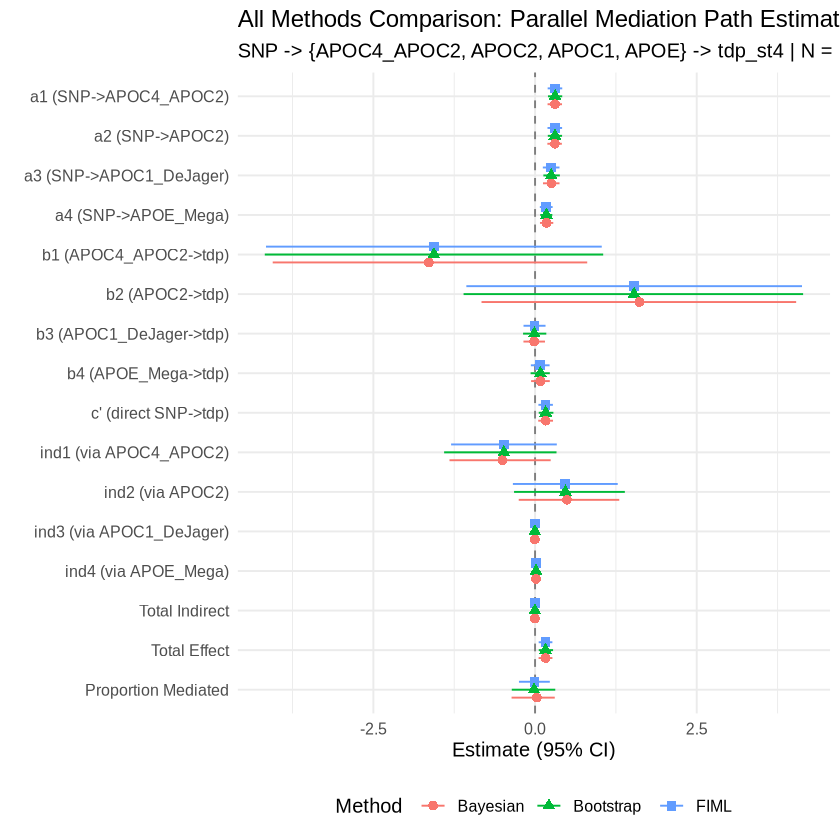

In [10]:
# ============================================================
# SUMMARY VISUALIZATIONS
# ============================================================

# E. All Methods Forest Plot
sum_plot <- all_summary[all_summary$label %in% key_labels, ]
sum_plot$display_label <- nice_labels[sum_plot$label]
sum_plot$display_label <- factor(sum_plot$display_label, levels=rev(nice_labels[key_labels]))

p_all_forest <- ggplot(sum_plot, aes(x=est, y=display_label, color=method, shape=method)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(aes(xmin=ci_lower, xmax=ci_upper), size=0.5,
                  position=position_dodge(width=0.6)) +
  labs(title="All Methods Comparison: Parallel Mediation Path Estimates",
       subtitle=paste0("SNP -> {APOC4_APOC2, APOC2, APOC1, APOE} -> tdp_st4 | N = ", N_total),
       x="Estimate (95% CI)", y="", color="Method", shape="Method") +
  theme_minimal(base_size=12) +
  theme(legend.position="bottom")

ggsave(file.path(dir_summ, "summary_forest_all_methods.png"), p_all_forest, width=12, height=10, dpi=150)
ggsave(file.path(dir_summ, "summary_forest_all_methods.pdf"), p_all_forest, width=12, height=10)
print(p_all_forest)
cat("Saved all-methods forest plot.\n")


Saved faceted-by-path plot.


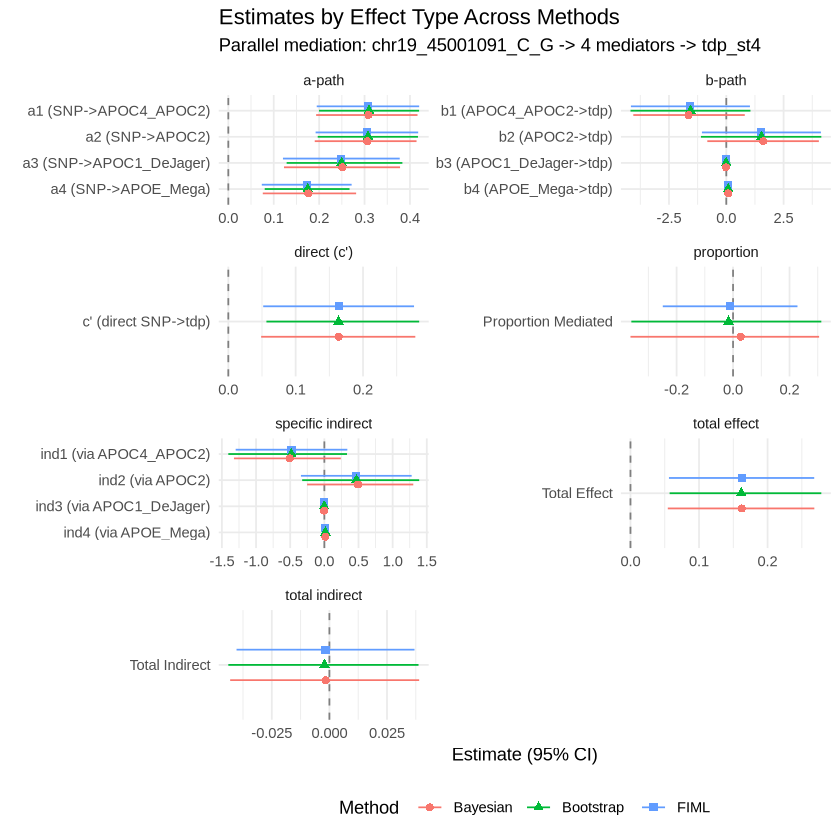

In [11]:
# F. Faceted by Effect Type
sum_plot$effect_type <- ifelse(grepl("^a", sum_plot$label), "a-path",
                        ifelse(grepl("^b", sum_plot$label), "b-path",
                        ifelse(sum_plot$label == "cp", "direct (c')",
                        ifelse(grepl("^ind[0-9]", sum_plot$label), "specific indirect",
                        ifelse(sum_plot$label == "total_indirect", "total indirect",
                        ifelse(sum_plot$label == "total", "total effect", "proportion"))))))

p_faceted <- ggplot(sum_plot, aes(x=est, y=display_label, color=method, shape=method)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(aes(xmin=ci_lower, xmax=ci_upper), size=0.4,
                  position=position_dodge(width=0.5)) +
  facet_wrap(~effect_type, scales="free", ncol=2) +
  labs(title="Estimates by Effect Type Across Methods",
       subtitle=paste0("Parallel mediation: ", exposure, " -> 4 mediators -> ", outcome),
       x="Estimate (95% CI)", y="", color="Method", shape="Method") +
  theme_minimal(base_size=11) +
  theme(legend.position="bottom")

ggsave(file.path(dir_summ, "summary_faceted_by_path.png"), p_faceted, width=14, height=12, dpi=150)
ggsave(file.path(dir_summ, "summary_faceted_by_path.pdf"), p_faceted, width=14, height=12)
print(p_faceted)
cat("Saved faceted-by-path plot.\n")


Saved indirect effect focus plot.


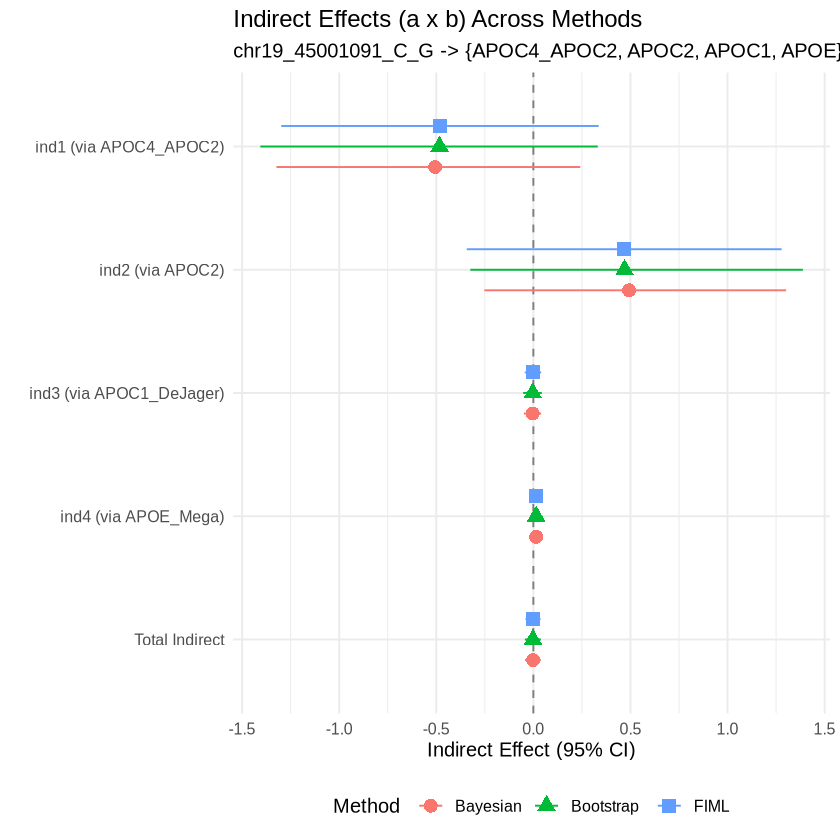

In [12]:
# G. Indirect Effect Focus
ind_focus <- sum_plot[sum_plot$label %in% c(paste0("ind", 1:n_med), "total_indirect"), ]

p_indirect <- ggplot(ind_focus, aes(x=est, y=display_label, color=method, shape=method)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(aes(xmin=ci_lower, xmax=ci_upper), size=0.8,
                  position=position_dodge(width=0.5)) +
  labs(title="Indirect Effects (a x b) Across Methods",
       subtitle=paste0(exposure, " -> {APOC4_APOC2, APOC2, APOC1, APOE} -> ", outcome, " | N = ", N_total),
       x="Indirect Effect (95% CI)", y="", color="Method", shape="Method") +
  theme_minimal(base_size=12) +
  theme(legend.position="bottom")

ggsave(file.path(dir_summ, "summary_indirect_effect.png"), p_indirect, width=10, height=6, dpi=150)
ggsave(file.path(dir_summ, "summary_indirect_effect.pdf"), p_indirect, width=10, height=6)
print(p_indirect)
cat("Saved indirect effect focus plot.\n")


Saved combined panel plot.


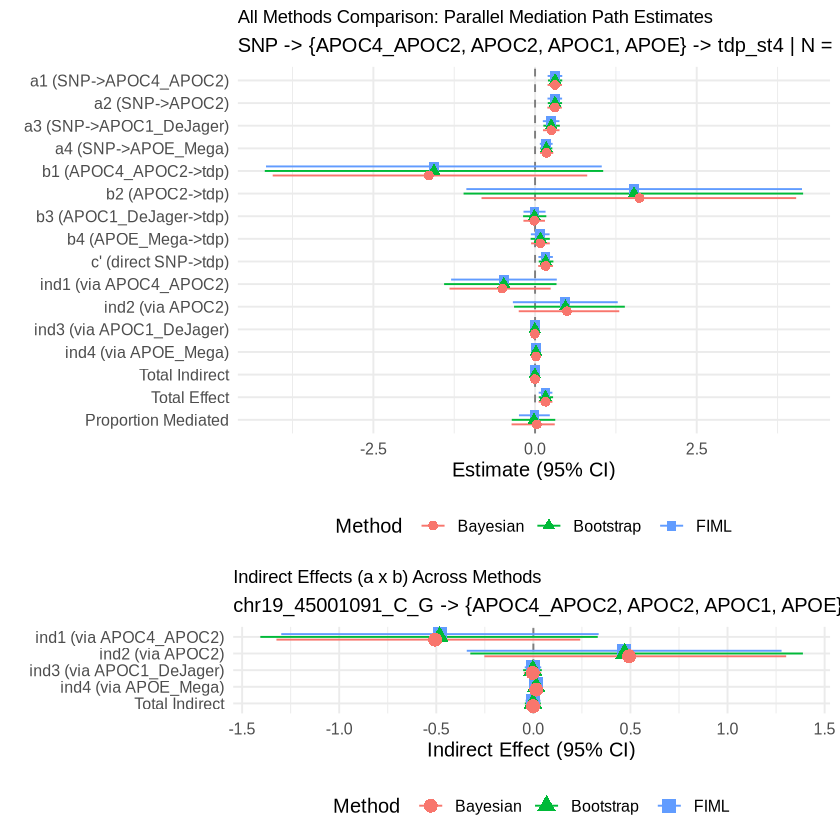

In [13]:
# H. Combined Panel
p_combined <- grid.arrange(
  p_all_forest + theme(plot.title=element_text(size=11)),
  p_indirect + theme(plot.title=element_text(size=11)),
  nrow=2, heights=c(2, 1)
)

g_combined <- arrangeGrob(
  p_all_forest + theme(plot.title=element_text(size=11)),
  p_indirect + theme(plot.title=element_text(size=11)),
  nrow=2, heights=c(2, 1)
)
ggsave(file.path(dir_summ, "summary_combined_panel.png"), g_combined, width=12, height=14, dpi=150)
ggsave(file.path(dir_summ, "summary_combined_panel.pdf"), g_combined, width=12, height=14)
cat("Saved combined panel plot.\n")


## Key Findings

In [14]:
# ============================================================
# KEY FINDINGS: Data-driven summary
# ============================================================

cat("=== KEY FINDINGS ===\n\n")

# Total indirect effect across methods
for (meth in unique(all_summary$method)) {
  ti_row <- all_summary[all_summary$method == meth & all_summary$label == "total_indirect", ]
  if (nrow(ti_row) == 1) {
    sig_star <- ifelse(!is.na(ti_row$pvalue) & ti_row$pvalue < 0.05, " *", "")
    cat(sprintf("%s: total_indirect = %.5f [%.5f, %.5f], p = %.4f%s\n",
                meth, ti_row$est, ti_row$ci_lower, ti_row$ci_upper, ti_row$pvalue, sig_star))
  }
}

cat("\n--- Specific Indirect Effects (FIML) ---\n")
for (i in 1:n_med) {
  lab <- paste0("ind", i)
  row_i <- fiml_res[fiml_res$label == lab, ]
  if (nrow(row_i) == 1) {
    sig_star <- ifelse(row_i$pvalue < 0.05, " *", "")
    cat(sprintf("  %s (via %s): %.5f [%.5f, %.5f], p = %.4f%s\n",
                lab, med_cols[i], row_i$est, row_i$ci_lower, row_i$ci_upper, row_i$pvalue, sig_star))
  }
}

cat("\n--- Direct Effect (c') ---\n")
cp_row <- fiml_res[fiml_res$label == "cp", ]
if (nrow(cp_row) == 1) {
  cat(sprintf("  c' = %.5f [%.5f, %.5f], p = %.4f\n",
              cp_row$est, cp_row$ci_lower, cp_row$ci_upper, cp_row$pvalue))
}

cat("\n--- Proportion Mediated ---\n")
pm_row <- fiml_res[fiml_res$label == "prop_med", ]
if (nrow(pm_row) == 1) {
  cat(sprintf("  Proportion mediated = %.3f (%.1f%%)\n", pm_row$est, 100*pm_row$est))
}

cat("\n--- MNAR Robustness ---\n")
cat(sprintf("  Tipping point distance: %.2f SD\n", tip_dist))


=== KEY FINDINGS ===



FIML: total_indirect = -0.00168 [-0.04031, 0.03694], p = 0.9319
Bootstrap: total_indirect = -0.00211 [-0.04388, 0.03869], p = 0.9080
Bayesian: total_indirect = -0.00159 [-0.04307, 0.03896], p = 0.9313



--- Specific Indirect Effects (FIML) ---


  ind1 (via APOC4_APOC2_AC_exp): -0.48107 [-1.29849, 0.33634], p = 0.2487
  ind2 (via APOC2_AC_exp): 0.46765 [-0.34302, 1.27833], p = 0.2582
  ind3 (via APOC1_DeJager_Mic_exp): -0.00205 [-0.04446, 0.04036], p = 0.9244
  ind4 (via APOE_Mega_Mic_exp): 0.01379 [-0.01239, 0.03996], p = 0.3020



--- Direct Effect (c') ---


  c' = 0.16377 [0.05179, 0.27575], p = 0.0041



--- Proportion Mediated ---


  Proportion mediated = -0.010 (-1.0%)



--- MNAR Robustness ---


  Tipping point distance: 1.55 SD


## Post-Analysis Sanity Check

In [15]:
# ============================================================
# SANITY CHECK
# ============================================================

passed <- c()
warnings_list <- c()
anomalies <- c()

# 1. Sign consistency
for (lab in c(paste0("ind", 1:n_med), "total_indirect", "cp", "total")) {
  signs <- c()
  for (meth in unique(all_summary$method)) {
    r <- all_summary[all_summary$method == meth & all_summary$label == lab, ]
    if (nrow(r) == 1 && !is.na(r$est)) signs <- c(signs, sign(r$est))
  }
  if (length(unique(signs)) > 1 && length(signs) > 1) {
    anomalies <- c(anomalies, paste0("Sign disagreement for ", lab, ": methods show different signs"))
  }
}
if (length(anomalies) == 0) passed <- c(passed, "Sign consistency: All methods agree on direction of effects")

# 2. Magnitude discrepancies
for (lab in c("total_indirect", paste0("ind", 1:n_med))) {
  ests <- c()
  for (meth in unique(all_summary$method)) {
    r <- all_summary[all_summary$method == meth & all_summary$label == lab, ]
    if (nrow(r) == 1 && !is.na(r$est)) ests <- c(ests, r$est)
  }
  if (length(ests) >= 2) {
    abs_ests <- abs(ests)
    pos_ests <- abs_ests[abs_ests > 0]
    if (length(pos_ests) >= 2 && max(pos_ests) > 3 * min(pos_ests)) {
      warnings_list <- c(warnings_list, paste0("Magnitude discrepancy for ", lab))
    }
  }
}
if (length(warnings_list) == 0) passed <- c(passed, "Magnitude consistency: No >3x discrepancies across methods")

# 3. Significance disagreements
for (lab in c("total_indirect", paste0("ind", 1:n_med))) {
  sig_status <- c()
  for (meth in unique(all_summary$method)) {
    r <- all_summary[all_summary$method == meth & all_summary$label == lab, ]
    if (nrow(r) == 1 && !is.na(r$pvalue)) {
      sig_status <- c(sig_status, paste0(meth, " p=", sprintf("%.4f", r$pvalue),
                                         ifelse(r$pvalue < 0.05, "*", "")))
    }
  }
  if (length(sig_status) > 0) {
    has_sig <- any(grepl("\\*", sig_status))
    has_ns  <- any(!grepl("\\*", sig_status))
    if (has_sig && has_ns) {
      warnings_list <- c(warnings_list, paste0("Significance disagreement (", lab, "): ",
                                                paste(sig_status, collapse=", ")))
    }
  }
}

# 4. Proportion mediated
pm_val <- fiml_res[fiml_res$label == "prop_med", "est"]
if (length(pm_val) == 1 && !is.na(pm_val)) {
  if (pm_val < 0) {
    warnings_list <- c(warnings_list, sprintf("Proportion mediated = %.3f (negative): suppression effect", pm_val))
  } else if (pm_val > 1) {
    warnings_list <- c(warnings_list, sprintf("Proportion mediated = %.3f (>1)", pm_val))
  } else {
    passed <- c(passed, sprintf("Proportion mediated = %.3f (in normal range 0-1)", pm_val))
  }
}

# 6. Bayesian convergence (if available)
if (!is.null(fit_bayes)) {
  tryCatch({
    conv_info <- blavInspect(fit_bayes, "rhat")
    max_rhat <- max(conv_info, na.rm=TRUE)
    if (max_rhat > 1.05) {
      anomalies <- c(anomalies, sprintf("Bayesian Rhat max = %.3f (> 1.05)", max_rhat))
    } else {
      passed <- c(passed, sprintf("Bayesian convergence: max Rhat = %.3f", max_rhat))
    }
  }, error = function(e) {
    warnings_list <<- c(warnings_list, "Could not check Bayesian Rhat")
  })
}

# 7. Bootstrap failure rate
boot_fail_rate <- 1 - n_converged / B
if (boot_fail_rate > 0.20) {
  anomalies <- c(anomalies, sprintf("High bootstrap failure rate: %d/%d converged", n_converged, B))
} else {
  passed <- c(passed, sprintf("Bootstrap convergence: %d/%d replicates (%.1f%%)", n_converged, B, 100*n_converged/B))
}

# 8. MNAR tipping point
if (!is.na(tip_dist) && is.finite(tip_dist) && tip_dist < 0.5) {
  warnings_list <- c(warnings_list, sprintf("MNAR tipping point = %.2f SD (fragile)", tip_dist))
} else if (!is.na(tip_dist) && is.finite(tip_dist)) {
  passed <- c(passed, sprintf("MNAR tipping point = %.2f SD", tip_dist))
}

# 10. Suppression
ti_est <- fiml_res[fiml_res$label == "total_indirect", "est"]
cp_est <- fiml_res[fiml_res$label == "cp", "est"]
if (length(ti_est)==1 && length(cp_est)==1 && !is.na(ti_est) && !is.na(cp_est)) {
  if (sign(ti_est) != sign(cp_est) && abs(ti_est) > 0.001 && abs(cp_est) > 0.001) {
    warnings_list <- c(warnings_list, "Indirect and direct effects have opposite signs (possible suppression)")
  }
}

# 11. Near-zero a or b with significant indirect
for (i in 1:n_med) {
  a_p <- fiml_res[fiml_res$label == paste0("a", i), "pvalue"]
  b_p <- fiml_res[fiml_res$label == paste0("b", i), "pvalue"]
  ind_p <- fiml_res[fiml_res$label == paste0("ind", i), "pvalue"]
  if (length(a_p)==1 && length(b_p)==1 && length(ind_p)==1) {
    if (!is.na(ind_p) && ind_p < 0.05) {
      if ((!is.na(a_p) && a_p > 0.1) || (!is.na(b_p) && b_p > 0.1)) {
        anomalies <- c(anomalies, sprintf("ind%d significant (p=%.4f) but a%d or b%d non-significant", i, ind_p, i, i))
      }
    }
  }
}

cat("\n=== Post-Analysis Sanity Check ===\n")
if (length(passed) > 0) {
  cat("\n### Passed\n")
  for (p in passed) cat("  [PASS]", p, "\n")
}
if (length(warnings_list) > 0) {
  cat("\n### Warnings\n")
  for (w in warnings_list) cat("  [WARN]", w, "\n")
}
if (length(anomalies) > 0) {
  cat("\n### Anomalies\n")
  for (a in anomalies) cat("  [ANOMALY]", a, "\n")
}
if (length(warnings_list) == 0 && length(anomalies) == 0) {
  cat("\nAll sanity checks passed -- no anomalies detected.\n")
}



=== Post-Analysis Sanity Check ===



### Passed
  [PASS] Sign consistency: All methods agree on direction of effects 
  [PASS] Magnitude consistency: No >3x discrepancies across methods 
  [PASS] Bayesian convergence: max Rhat = 1.035 
  [PASS] Bootstrap convergence: 1000/1000 replicates (100.0%) 
  [PASS] MNAR tipping point = 1.55 SD 



### Warnings
  [WARN] Proportion mediated = -0.010 (negative): suppression effect 
  [WARN] Indirect and direct effects have opposite signs (possible suppression) 


## Output File Inventory

In [16]:
# ============================================================
# OUTPUT FILE INVENTORY
# ============================================================
cat("=== Output File Inventory ===\n")
all_files <- list.files(RESULT_DIR, recursive=TRUE, full.names=FALSE)
for (f in sort(all_files)) {
  full_path <- file.path(RESULT_DIR, f)
  size_kb <- file.info(full_path)$size / 1024
  cat(sprintf("  %-70s  %.1f KB\n", f, size_kb))
}


=== Output File Inventory ===


  APOE_ind_set_27_tdp_st4_APOE4_2_adj_SEM_mediation_bayesian_fix.ipynb    40.6 KB
  APOE_ind_set_27_tdp_st4_APOE4_2_adj_SEM_mediation.ipynb                 59.3 KB
  bayesian_blavaan/bayesian_forest_plot.pdf                               6.7 KB
  bayesian_blavaan/bayesian_forest_plot.png                               108.9 KB
  bayesian_blavaan/bayesian_posteriors_chr19_45001091_C_G.pdf             65.8 KB
  bayesian_blavaan/bayesian_posteriors_chr19_45001091_C_G.png             271.6 KB
  bayesian_blavaan/bayesian_results.csv                                   2.9 KB
  bayesian_blavaan/bayesian_trace_a_chr19_45001091_C_G.pdf                45.9 KB
  bayesian_blavaan/bayesian_trace_a_chr19_45001091_C_G.png                296.6 KB
  bootstrap/bootstrap_distributions_chr19_45001091_C_G.pdf                7.5 KB
  bootstrap/bootstrap_distributions_chr19_45001091_C_G.png                84.3 KB
  bootstrap/bootstrap_forest_plot.pdf                                     6.6 KB
  bootstrap/boots

In [17]:
# ============================================================
# SESSION NOTES
# ============================================================
session_notes <- paste0(
  "# Session Notes: Parallel Mediation Analysis\n\n",
  "## Analysis\n",
  "- Design: Parallel mediation (Design 2) with 4 mediators\n",
  "- Exposure: ", exposure, "\n",
  "- Mediators: ", paste(med_cols, collapse=", "), "\n",
  "- Outcome: ", outcome, "\n",
  "- Direction: Unidirectional (SNP -> M -> Y)\n",
  "- N total: ", N_total, "\n",
  "- Methods: FIML SEM, Bootstrap (1000 replicates), MNAR Sensitivity, Bayesian SEM\n\n",
  "## Key Findings\n",
  "- See all_methods_summary.csv for detailed results\n",
  "- Bootstrap convergence: ", n_converged, "/", B, " replicates\n",
  "- MNAR tipping point distance: ", sprintf("%.2f", tip_dist), " SD\n\n",
  "## Fixes Applied\n",
  "- Bayesian extraction code was rewritten to robustly handle blavaan's internal\n",
  "  parameter naming (pxnames mapping) and manually compute defined parameters\n",
  "  (indirect effects, total, proportion mediated) from regression parameter draws.\n",
  "- Original error: 'arguments imply differing number of rows: 1, 0' caused by\n",
  "  parTable label matching failure for defined (:=) parameters.\n\n",
  "## Sanity Check\n",
  if (length(anomalies) > 0) paste0("ANOMALIES: ", paste(anomalies, collapse="; "), "\n") else "No anomalies detected.\n",
  if (length(warnings_list) > 0) paste0("WARNINGS: ", paste(warnings_list, collapse="; "), "\n") else "",
  "\n## Next Steps\n",
  "- Examine specific indirect effects to identify which mediator(s) carry the SNP effect\n",
  "- Consider follow-up with individual mediator models if specific indirects differ greatly\n",
  "- Assess biological plausibility of dominant mediator pathway(s)\n"
)

writeLines(session_notes, file.path(RESULT_DIR, "session_notes.md"))
cat("Saved session_notes.md\n")


Saved session_notes.md


In [18]:
# ============================================================
# CLEANUP + SESSION INFO
# ============================================================
for (pat in c("lavExport")) {
  dirs_to_rm <- list.dirs(RESULT_DIR, recursive=TRUE, full.names=TRUE)
  for (d in dirs_to_rm) {
    if (grepl(pat, basename(d))) unlink(d, recursive=TRUE)
  }
}
for (pat in c("\\.stan$", "^tmp_", "\\.bak$")) {
  files_to_rm <- list.files(RESULT_DIR, pattern=pat, recursive=TRUE, full.names=TRUE)
  if (length(files_to_rm) > 0) file.remove(files_to_rm)
}

cat("\n=== Session Info ===\n")
sessionInfo()



=== Session Info ===


Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”


R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 24.04.3 LTS

Matrix products: default
BLAS/LAPACK: /mnt/lustre/home/yl4437/.pixi/envs/python/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] reshape2_1.4.5 gridExtra_2.3  ggplot2_4.0.2  blavaan_0.5-10 Rcpp_1.1.1    
[6] lavaan_0.6-21 

loaded via a namespace (and not attached):
 [1] gtable_0.3.6          QuickJSR_1.9.0        inline_0.3.21        
 [4] CompQuadForm_1.4.4    lattice_0.22-9        quadprog_1.5-8       
 [7] vc